In [132]:
EMA_path = "./../inference/combined/EMA_manually_cleaned.json"
JAPAN_path = "./../inference/combined/JAPAN_manually_cleaned.json"
SWISSMEDIC_path = "./../inference/combined/SWISSMEDIC_manually_cleaned.json"
AUSTRALIA_path = "./../inference/combined/AUSTRALIA_manually_cleaned.json"
FDA_path = "./../inference/combined/FDA_manually_cleaned.json"
HEALTHCANADA_path = "./../inference/combined/HEALTHCANADA_manually_cleaned.json"

SAVE_DIR = "./../inference/combined/figures/"
import os
os.makedirs(SAVE_DIR, exist_ok=True)

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as mcolors
import seaborn as sns
import json
import numpy as np
from matplotlib.ticker import FixedLocator, ScalarFormatter
import math

In [134]:
def load_data(file_path):
    """Load data from a JSON file."""
    with open(file_path, 'r', encoding="utf-8") as file:
        data = json.load(file)
    return pd.DataFrame(data)

def to_lower(df):
    return df.map(lambda x: x.lower().strip() if isinstance(x, str) else x)

def remove_invalid_rows(df):
    invalid_rows = df.apply(lambda x: x.astype(str).str.contains("the response is not valid json", case=False, na=False))
    print(f"Total rows with invalid responses: {invalid_rows.any(axis=1).sum()}")
    df = df[~invalid_rows.any(axis=1)]
    return df

def prepare_for_analysis(filepath):
    df = load_data(filepath)
    df = df.transpose()
    df.replace(["not reported", "Not reported", ""], np.nan, inplace=True)
    df = remove_invalid_rows(df)
    df = to_lower(df)
    return df

def generate_distinct_colors(n, cmap_name='tab20'):
    cmap = cm.get_cmap(cmap_name, n)
    return [mcolors.rgb2hex(cmap(i)) for i in range(n)]

def date_to_int(df, col_name):
    df = df.copy()
    original_len = len(df)

    # 1) Versuchen, direkt als Zahl zu interpretieren
    numeric_years = pd.to_numeric(df[col_name], errors='coerce')

    # 2) Nur plausible Jahreszahlen behalten
    numeric_years = numeric_years.where(numeric_years.between(1800, 2100))

    # 3) Falls kein valider Jahrwert -> als Datum interpretieren
    dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year

    # 4) Jahreswerte bevorzugen, sonst Datum-Jahr nehmen
    df[col_name] = numeric_years.fillna(dt_years).astype('Int64')

    # 5) Ungültige Werte entfernen
    df = df.dropna(subset=[col_name])
    df[col_name] = df[col_name].astype(int)

    final_len = len(df)
    print(f"Original length: {original_len}, Final length after cleaning: {final_len}, "
          f"Percentage kept: {final_len/original_len*100:.2f}%")
    return df

def plot_timeline(df, col_name, dataset_name=None):
    df = date_to_int(df, col_name)  # Ensure column is integer (e.g., year)
    unique_vals = sorted(df[col_name].unique())
    bins = np.append(unique_vals, unique_vals[-1] + 1)
    plt.figure(figsize=(8, 4))
    ax = plt.gca()
    counts, edges, patches = plt.hist(df[col_name], bins=bins, color="seagreen", edgecolor='black', align='left', alpha=0.7)
    ax.set_xticks(unique_vals)
    ax.set_xticklabels([str(int(x)) for x in unique_vals], rotation=45, ha='center')
    plt.xlabel(col_name)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}timeline_{col_name}_{dataset_name}.png", dpi=300, bbox_inches='tight')
    plt.close()

def plot_drug_class_per_application_year_absolute(df, date_col='Application_date', drug_class_colormap=None, dataset_name=None):
    # preprocessing
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Drug_class', date_col])
    df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    # date -> year
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])
    df['Year'] = df[date_col].dt.year.astype(int)

    # grouping
    count_df = df.groupby(['Year', 'Drug_class']).size().unstack(fill_value=0)

    # Ensure colormap is complete
    if drug_class_colormap is None:
        colors = generate_distinct_colors(len(count_df.columns), cmap_name='nipy_spectral')
    else:
        colors = [drug_class_colormap.get(cls, '#333333') for cls in count_df.columns]

    # Plot
    count_df.plot(
        kind='bar',
        stacked=True,
        figsize=(12, 6),
        color=colors,
        edgecolor='black'
    )

    plt.ylabel('Number of Drugs')
    plt.xlabel('Year')
    plt.title('Drug Class Distribution per Year (Absolute Counts)')
    plt.legend(title='Drug Class', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}drug_class_per_application_year_absolute_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_drug_class_per_decision_year_absolute(df, year_col='Decision_year', drug_class_colormap=None, dataset_name=None):
    # Vorverarbeitung
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Drug_class', year_col])
    df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    # Decision_year -> Year (int) mit deiner date_to_int-Funktion
    df = date_to_int(df, year_col)
    df.rename(columns={year_col: 'Year'}, inplace=True)

    # Gruppierung (Jahre sortieren)
    count_df = (
        df.groupby(['Year', 'Drug_class'])
          .size()
          .unstack(fill_value=0)
          .sort_index()
    )

    # Farbzuordnung
    if drug_class_colormap is None:
        colors = generate_distinct_colors(len(count_df.columns), cmap_name='nipy_spectral')
    else:
        colors = [drug_class_colormap.get(cls, '#333333') for cls in count_df.columns]

    # Plot
    ax = count_df.plot(
        kind='bar',
        stacked=True,
        figsize=(12, 6),
        color=colors,
        edgecolor='black'
    )

    ax.set_ylabel('Number of Drugs')
    ax.set_xlabel('Year')
    ax.set_title('Drug Class Distribution per Year (Absolute Counts)')
    ax.legend(title='Drug Class', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}drug_class_per_decision_year_absolute_{dataset_name}.png",
                    dpi=300, bbox_inches='tight')

def plot_drug_class_per_year(df, date_col=None, drug_class_colormap=None, dataset_name=None):
    # Vorverarbeitung
    df = df.copy()
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Drug_class', date_col])
    df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    # Datum/Jahr mit deiner Hilfsfunktion robust auf Integer-Jahre mappen
    df = date_to_int(df, date_col)             # -> col wird int-Jahr
    df = df.rename(columns={date_col: 'Year'}) # konsistent weiterarbeiten

    # Gruppieren
    count_df = (
        df.groupby(['Year', 'Drug_class'])
          .size()
          .unstack(fill_value=0)
          .sort_index()
    )

    # Auf 100% normalisieren (Zeilenweise)
    denom = count_df.sum(axis=1).replace(0, np.nan)
    percent_df = (count_df.T / denom).T.fillna(0) * 100

    # Farben
    if drug_class_colormap is None:
        colors = generate_distinct_colors(len(percent_df.columns), cmap_name='nipy_spectral')
    else:
        colors = [drug_class_colormap.get(cls, '#333333') for cls in percent_df.columns]

    # Plot
    ax = percent_df.plot(
        kind='bar',
        stacked=True,
        figsize=(12, 6),
        color=colors,
        edgecolor='black'
    )
    ax.set_ylabel('Percentage of Drugs')
    ax.set_xlabel('Year')
    ax.set_title(dataset_name)
    ax.legend(title='Drug Class', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # X-Achse explizit als Integer-Jahre labeln (verhindert 2008.0)
    ax.set_xticks(range(len(percent_df.index)))
    ax.set_xticklabels([str(int(y)) for y in percent_df.index], rotation=45, ha='right')

    plt.tight_layout()
    if dataset_name:
        plt.savefig(f"{SAVE_DIR}drug_class_per_year_stacked_{date_col}_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_drug_class_distribution_pie(df, drug_class_colormap=None, dataset_name=None):
    df = df.copy()
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Drug_class'])
    df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    class_counts = df['Drug_class'].value_counts()
    labels = class_counts.index
    sizes = class_counts.values

    # Ensure colormap is complete
    if drug_class_colormap is None:
        drug_class_colormap = {}
    cmap = plt.get_cmap('tab20')
    for i, label in enumerate(labels):
        if label not in drug_class_colormap:
            drug_class_colormap[label] = cmap(i % cmap.N)

    colors = [drug_class_colormap[label] for label in labels]
    total = sizes.sum()

    plt.figure(figsize=(5, 5))
    wedges, _ = plt.pie(
        sizes,
        startangle=140,
        colors=colors,
        wedgeprops=dict(width=0.3, edgecolor='w'),
    )
    legend_labels = [f"{label} ({size / total * 100:.1f}%)" for label, size in zip(labels, sizes)]

    plt.title(dataset_name)

    plt.legend(
        wedges,
        legend_labels,
        title='Drug Class',
        loc='center left',
        bbox_to_anchor=(1, 0.7),
        fontsize=9
    )
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}drug_class_distribution_pie_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_drug_class_by_administration_route(df, dataset_name=None):
    df = df.copy()
    
    # Preprocessing
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Drug_class', 'Administration_route'])
    df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    # split administration routes and clean whitespace
    df['Administration_route'] = df['Administration_route'].str.replace('„|“|”', '"')  # typografische Anführungszeichen entfernen
    df['Administration_route'] = df['Administration_route'].str.split(';')
    df = df.explode('Administration_route')
    df['Administration_route'] = df['Administration_route'].str.strip()

    # Count occurrences of drug classes by administration route
    class_counts = df.groupby(['Drug_class', 'Administration_route']).size().unstack(fill_value=0)
    class_counts = class_counts.loc[class_counts.sum(axis=1).sort_values(ascending=False).index]

    # Farben generieren mit generate_distinct_colors
    colors = generate_distinct_colors(len(class_counts.index), cmap_name='nipy_spectral')

    # Plot
    class_counts.plot(
        kind='bar',
        stacked=True,
        color=colors,
        edgecolor='black',
        figsize=(10, 6)
    )

    plt.xlabel('Drug Class')
    plt.ylabel('Number of Drugs')
    plt.legend(title='Administration Route', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}drug_class_by_administration_route_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_administration_route_per_year(df, agency_name, date_col='Application_date', dataset_name=None):
    df = df.copy()
    
    # preprocessing
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Administration_route', date_col])
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])
    df['Year'] = df[date_col].dt.year.astype(int)

    # if multiple administration routes are separated by ';'
    df['Administration_route'] = df['Administration_route'].str.replace('„|“|“', '"')  # typografische Anführungszeichen entfernen
    df['Administration_route'] = df['Administration_route'].str.split(';')
    df = df.explode('Administration_route')
    df['Administration_route'] = df['Administration_route'].str.strip()

    # Ggroup and normalize
    count_df = df.groupby(['Year', 'Administration_route']).size().unstack(fill_value=0)
    percent_df = count_df.div(count_df.sum(axis=1), axis=0) * 100  # auf 100% normieren

    cmap = plt.get_cmap('tab20', len(percent_df.columns))
    colors = [cmap(i) for i in range(len(percent_df.columns))]

    # Plot
    percent_df.plot(
        kind='bar',
        stacked=True,
        figsize=(12, 6),
        color=colors,
        edgecolor='black'
    )
    plt.title(agency_name)
    plt.xlabel('Year')
    plt.ylabel('Percentage of Drugs')
    plt.legend(title='Administration Route', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}administration_route_per_year_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_drug_class_by_pharmaceutical_form(df, dataset_name=None):
    df = df.copy()
    
    # Preprocessing
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Drug_class', 'Pharmaceutical_form'])
    df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    # Split pharmaceutical forms and clean whitespace
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.replace('„|“|”', '"')  # typografische Anführungszeichen entfernen
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.split(';')
    df = df.explode('Pharmaceutical_form')
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.strip()

    # Count occurrences of drug classes by pharmaceutical form
    class_counts = df.groupby(['Drug_class', 'Pharmaceutical_form']).size().unstack(fill_value=0)
    class_counts = class_counts.loc[class_counts.sum(axis=1).sort_values(ascending=False).index]

    # Farben generieren für die Spalten (Pharmaceutical Forms)
    colors = generate_distinct_colors(len(class_counts.columns), cmap_name='nipy_spectral')

    # Plot
    class_counts.plot(
        kind='bar',
        stacked=True,
        color=colors,
        edgecolor='black',
        figsize=(10, 6)
    )

    plt.xlabel('Drug Class')
    plt.ylabel('Number of Drugs')
    plt.title(dataset_name)
    plt.legend(title='Pharmaceutical Form', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}drug_class_by_pharmaceutical_form_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_pharmaceutical_form_per_year(df, agency_name, date_col=None, dataset_name=None):
    df = df.copy()

    # preprocessing
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Pharmaceutical_form', date_col])
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])
    df['Year'] = df[date_col].dt.year.astype(int)

    # if multiple pharmaceutical forms are separated by ';'
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.replace('„|“|“', '"')  # typografische Anführungszeichen entfernen
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.split(';')
    df = df.explode('Pharmaceutical_form')
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.strip()

    # group and normalize
    count_df = df.groupby(['Year', 'Pharmaceutical_form']).size().unstack(fill_value=0)
    percent_df = count_df.div(count_df.sum(axis=1), axis=0) * 100  # auf 100% normieren

    # Count occurrences of drug classes by pharmaceutical form
    class_counts = df.groupby(['Drug_class', 'Pharmaceutical_form']).size().unstack(fill_value=0)
    class_counts = class_counts.loc[class_counts.sum(axis=1).sort_values(ascending=False).index]
    # Ensure colormap is complete
    # colors = generate_distinct_colors(len(class_counts.index), cmap_name='nipy_spectral')
    colors = generate_distinct_colors(len(percent_df.columns), cmap_name='tab20')

    # Plot
    percent_df.plot(
        kind='bar',
        stacked=True,
        figsize=(12, 6),
        color=colors,
        edgecolor='black'
    )
    plt.title(agency_name)
    plt.xlabel('Year')
    plt.ylabel('Percentage of Drugs')
    plt.legend(title='Pharmaceutical Form', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}pharmaceutical_form_per_year_{date_col}_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_disease_class_per_decision_year_absolute(
    df, year_col=None, disease_class_colormap=None, dataset_name=None
):
    disease_col = 'Disease_class(es)'

    # Vorverarbeitung
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=[disease_col, year_col])
    df = df[~df[disease_col].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    # Decision_year -> Year (int) mit deiner date_to_int-Funktion
    df = date_to_int(df, year_col)
    df.rename(columns={year_col: 'Year'}, inplace=True)

    # Mehrfachangaben aufsplitten
    df[disease_col] = df[disease_col].astype(str).str.split(';')
    df = df.explode(disease_col)
    df[disease_col] = df[disease_col].str.strip()  # Leerzeichen entfernen
    df = df[df[disease_col] != '']  # Leere Werte entfernen

    # Top 2 Disease Classes ausgeben
    top_classes = df[disease_col].value_counts().head(2)
    print("\nTop 2 Disease Classes (absolute Häufigkeit):")
    for cls, count in top_classes.items():
        print(f"{cls}: {count}")

    # Gruppierung (Jahre sortieren)
    count_df = (
        df.groupby(['Year', disease_col])
          .size()
          .unstack(fill_value=0)
          .sort_index()
    )

    # Farbzuordnung mit deiner Funktion
    if disease_class_colormap is None:
        colors = generate_distinct_colors(len(count_df.columns))
    else:
        colors = [disease_class_colormap.get(cls, '#333333') for cls in count_df.columns]

    # Plot
    ax = count_df.plot(
        kind='bar',
        stacked=True,
        figsize=(12, 6),
        color=colors,
        edgecolor='black'
    )

    ax.set_ylabel('Number of Drugs')
    ax.set_xlabel('Year')
    ax.set_title(dataset_name)
    ax.legend(title='Disease Class', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}disease_class_per_decision_year_absolute_{dataset_name}.png",
                    dpi=300, bbox_inches='tight')

def plot_marketing_holder_distribution_pie(df, holder_colormap=None, dataset_name=None):
    df = df.copy()
    
    # Vorverarbeitung
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Marketing_authorisation_holder_extracted'])
    df = df[~df['Marketing_authorisation_holder_extracted'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]
    
    # Zähle eindeutige Marketing Holder
    holder_counts = df['Marketing_authorisation_holder_extracted'].str.strip().str.lower().value_counts()

    # Split into top 30 and others (nur eindeutige Einträge)
    if len(holder_counts) > 30:
        top_counts = holder_counts.nlargest(30)
        others_labels = holder_counts.iloc[30:].index.tolist()
        others_count = len(others_labels)  # Nur eindeutige Einträge zählen

        # Append 'Other' category
        top_counts['Other'] = others_count
        holder_counts = top_counts

    labels = holder_counts.index
    sizes = holder_counts.values

    # Ensure colormap is complete
    if holder_colormap is None:
        holder_colormap = {}
    cmap = plt.get_cmap('tab20')
    for i, label in enumerate(labels):
        if label not in holder_colormap:
            holder_colormap[label] = cmap(i % cmap.N)

    colors = [holder_colormap[label] for label in labels]
    total = sizes.sum()

    plt.figure(figsize=(10, 5))
    wedges, _ = plt.pie(
        sizes,
        startangle=140,
        colors=colors,
        wedgeprops=dict(width=0.3, edgecolor='w'),
    )

    # Für die Legende: bei "Other" auch Anzahl einfügen
    legend_labels = []
    for label, size in zip(labels, sizes):
        if label == 'Other':
            legend_labels.append(f"Other ({size} unique holders, {size / total * 100:.1f}%)")
        else:
            legend_labels.append(f"{label} ({size / total * 100:.1f}%)")

    plt.legend(
        wedges,
        legend_labels,
        title='Marketing Authorisation Holder',
        loc='center left',
        bbox_to_anchor=(1, 0.7),
        fontsize=9
    )
    plt.title(dataset_name)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}marketing_holder_distribution_pie_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_review_duration_by_agency(agency_dfs: dict, submission_col='Application_date', decision_col='Decision_date', dataset_name=None):
   
    combined_list = []

    # calculate review duration for each agency
    for agency, df in agency_dfs.items(): 
        if "Application_date" in df.columns and "Decision_date" in df.columns:
            df = df.copy()
            df[submission_col] = pd.to_datetime(df[submission_col], errors='coerce', dayfirst=True)
            df[decision_col] = pd.to_datetime(df[decision_col], errors='coerce', dayfirst=True)
            
            # Calculate duration
            df['Review_duration_days'] = (df[decision_col] - df[submission_col]).dt.days
            
            # Keep only valid positive durations
            valid = df[(df['Review_duration_days'] > 0) & (~df['Review_duration_days'].isna())]
            
            valid['Agency'] = agency
            combined_list.append(valid[['Review_duration_days', 'Agency']])
        else:
            print(f"{agency}: Missing required columns for review duration calculation.")

    combined_df = pd.concat(combined_list, ignore_index=True)

    # add overall data
    overall_df = combined_df.copy()
    overall_df['Agency'] = 'Overall'
    combined_df = pd.concat([combined_df, overall_df], ignore_index=True)

    # Plot
    plt.figure(figsize=(10, 6))
    ax = sns.boxplot(data=combined_df, x='Agency', y='Review_duration_days', palette='tab20')
    ax.set_ylabel('Review Duration (days, log scale)')
    ax.set_xlabel('Agency')
    ax.set_yscale("symlog", linthresh=500)
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_minor_formatter(ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')
    ax.set_yticks([100, 200, 300, 400, 500, 700, 1000, 1500, 2000])
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}review_duration_by_agency_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_review_duration_by_disease_class(df, submission_col=None, decision_col=None, dataset_name=None):
   
    df = df.copy()
    df[submission_col] = pd.to_datetime(df[submission_col], errors='coerce', dayfirst=True)
    df[decision_col] = pd.to_datetime(df[decision_col], errors='coerce', dayfirst=True)
    df['Review_duration_days'] = (df[decision_col] - df[submission_col]).dt.days

    # Filter out invalid durations and disease classes
    df = df.dropna(subset=['Review_duration_days', 'Disease_class(es)'])
    df = df[df['Review_duration_days'] > 0]

    # Split disease classes and clean whitespace
    df['Disease_class(es)'] = df['Disease_class(es)'].str.split(';')
    df = df.explode('Disease_class(es)')
    df['Disease_class(es)'] = df['Disease_class(es)'].str.strip()  # clean whitespace

    # Plot
    plt.figure(figsize=(12, 6))
    ax = sns.boxplot(data=df, x='Disease_class(es)', y='Review_duration_days', palette='tab20')
    ax.set_ylabel('Review Duration (days)')
    ax.set_xlabel('Disease Class')
    ax.set_yscale("symlog", linthresh=500)
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_minor_formatter(ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')
    ax.set_yticks([200, 400, 600, 800, 1000, 1500])
    plt.xticks(rotation=45, ha='right')
    plt.title(dataset_name)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Save the plot
    if dataset_name:
        filename = f"plot_review_duration_by_disease_class_{dataset_name}.png"
        plt.savefig(os.path.join(SAVE_DIR, filename), dpi=300, bbox_inches='tight')

def plot_decision_distribution_by_agency(agency_dfs: dict, dataset_name=None):
  
    # Prepare data for plotting
    all_counts = []

    for agency, df in agency_dfs.items():
        df = df.copy()
        if 'Decision' not in df.columns:
            continue
        decision_counts = df['Decision'].str.lower().value_counts(normalize=True) * 100
        for decision, percent in decision_counts.items():
            all_counts.append({'Agency': agency, 'Decision': decision, 'Percent': percent})

    plot_df = pd.DataFrame(all_counts)

    # Pivot the DataFrame for plotting
    pivot_df = plot_df.pivot(index='Agency', columns='Decision', values='Percent').fillna(0)
    pivot_df = pivot_df.loc[sorted(pivot_df.index)]  

    # Plot
    pivot_df.plot(
        kind='bar',
        stacked=True,
        colormap='tab20',
        edgecolor='black',
        figsize=(8, 5)
    )

    plt.ylabel('Percentage of Decisions')
    plt.xlabel('Agency')
    plt.ylim(0, 100)
    plt.title('Decision Distribution per Agency (100% stacked)')
    plt.legend(title='Decision', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}decision_distribution_by_agency_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_decision_breakdown_per_disease_class(df, dataset_name=None, date_col='Decision_date'):
    df = df.copy()

    # preprocessing
    df['Decision'] = df['Decision'].astype(str).str.lower()
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=True)
    df['Year'] = df[date_col].dt.year
    df = df.dropna(subset=['Year', 'Decision', 'Disease_class(es)'])
    df['Year'] = df['Year'].astype(int)

    if "Disease_class(es)" in df.columns:
        count_disease = df.groupby(['Disease_class(es)', 'Decision']).size().unstack(fill_value=0)
        top_classes = count_disease.sum(axis=1).nlargest(10).index
        count_disease = count_disease.loc[top_classes]

        count_disease.plot(kind='bar', stacked=True, figsize=(12, 6), edgecolor='black')
        plt.title(dataset_name)
        plt.xlabel('Disease Class')
        plt.ylabel('Number of Decisions')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        if dataset_name:
            plt.savefig(f"{SAVE_DIR}decision_distribution_by_disease_class_{dataset_name}.png",
                        dpi=300, bbox_inches='tight')
    else:
        print(f"{dataset_name}: 'Disease_class(es)' column not found for decision breakdown by disease class.")



def plot_decision_breakdown_per_agency_per_year(df, dataset_name=None, date_col='Decision_date'):
    df = df.copy()

    # preprocessing
    df['Decision'] = df['Decision'].astype(str).str.lower()
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=True)
    df['Year'] = df[date_col].dt.year
    df = df.dropna(subset=['Year', 'Decision'])
    df['Year'] = df['Year'].astype(int)

    count_year = df.groupby(['Year', 'Decision']).size().unstack(fill_value=0).sort_index()
    count_year.plot(kind='bar', stacked=True, figsize=(10, 5), edgecolor='black')
    plt.title(dataset_name)
    plt.xlabel('Year')
    plt.ylabel('Number of Decisions')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    if dataset_name:
        plt.savefig(f"{SAVE_DIR}decision_distribution_by_year_{dataset_name}.png",
                    dpi=300, bbox_inches='tight')

def plot_nonclinical_abridged_distribution(agency_dfs: dict, dataset_name=None):
    all_data = []

    # prepare data for plotting
    for agency, df in agency_dfs.items():
        df = df.copy()
        if 'Nonclinical_abridged' not in df.columns:
            continue
        df['Nonclinical_abridged'] = df['Nonclinical_abridged'].str.lower().str.strip()
        counts = df['Nonclinical_abridged'].value_counts(normalize=True) * 100
        for status in ['yes', 'no']:
            all_data.append({
                'Agency': agency,
                'Status': status,
                'Percent': counts.get(status, 0.0)
            })

    # Combine overall data
    overall_df = pd.concat(agency_dfs.values(), ignore_index=True)
    if 'Nonclinical_abridged' in overall_df.columns:
        overall_df['Nonclinical_abridged'] = overall_df['Nonclinical_abridged'].str.lower().str.strip()
        counts = overall_df['Nonclinical_abridged'].value_counts(normalize=True) * 100
        for status in ['yes', 'no']:
            all_data.append({
                'Agency': 'Overall',
                'Status': status,
                'Percent': counts.get(status, 0.0)
            })

    plot_df = pd.DataFrame(all_data)

    # Pivot the DataFrame for plotting
    pivot_df = plot_df.pivot(index='Agency', columns='Status', values='Percent').fillna(0)
    if 'yes' not in pivot_df.columns:
        pivot_df['yes'] = 0.0
    if 'no' not in pivot_df.columns:
        pivot_df['no'] = 0.0
    pivot_df = pivot_df[['yes', 'no']] 

    # Plot
    pivot_df.plot(
        kind='bar',
        stacked=True,
        color=['#4daf4a', '#e41a1c'],
        edgecolor='black',
        figsize=(6, 4)
    )

    plt.ylabel('Percentage of Submissions')
    plt.xlabel('Agency')
    # plt.title('Share of Nonclinical Abridged Submissions per Agency (100% Stacked)')
    plt.ylim(0, 100)
    plt.legend(title='Nonclinical Abridged', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}nonclinical_abridged_distribution_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_orphan_drug_status_distribution(agency_dfs: dict, dataset_name=None):
    all_data = []

    # prepare data for plotting
    for agency, df in agency_dfs.items():
        df = df.copy()
        if 'Orphan_drug_status' not in df.columns:
            continue
        df['Orphan_drug_status'] = df['Orphan_drug_status'].str.lower().str.strip()
        counts = df['Orphan_drug_status'].value_counts(normalize=True) * 100
        for status in ['yes', 'no']:
            all_data.append({
                'Agency': agency,
                'Status': status,
                'Percent': counts.get(status, 0.0)
            })

    # Combine overall data
    overall_df = pd.concat(agency_dfs.values(), ignore_index=True)
    if 'Orphan_drug_status' in overall_df.columns:
        overall_df['Orphan_drug_status'] = overall_df['Orphan_drug_status'].str.lower().str.strip()
        counts = overall_df['Orphan_drug_status'].value_counts(normalize=True) * 100
        for status in ['yes', 'no']:
            all_data.append({
                'Agency': 'Overall',
                'Status': status,
                'Percent': counts.get(status, 0.0)
            })

    plot_df = pd.DataFrame(all_data)

    # Pivot the DataFrame for plotting
    pivot_df = plot_df.pivot(index='Agency', columns='Status', values='Percent').fillna(0)
    for status in ['yes', 'no']:
        if status not in pivot_df.columns:
            pivot_df[status] = 0.0
    pivot_df = pivot_df[['yes', 'no']] 

    # Plot
    pivot_df.plot(
        kind='bar',
        stacked=True,
        color=['#377eb8', '#f781bf'], 
        edgecolor='black',
        figsize=(6, 4)
    )

    plt.ylabel('Percentage of Submissions')
    plt.xlabel('Agency')
    # plt.title('Share of Orphan Drug Status per Agency (100% Stacked)')
    plt.ylim(0, 100)
    plt.legend(title='Orphan Drug Status', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}orphan_drug_status_distribution_{dataset_name}.png", dpi=300, bbox_inches='tight')

# === Disease Burden Plots ===

# === 1) Kanonische Disease Classes & Mapping-Funktionen ===

CANONICAL_CLASSES = [
    "Infectious and parasitic diseases",
    "Neoplasms",
    "Diseases of the blood and blood-forming organs",
    "Endocrine, nutritional, and metabolic diseases",
    "Mental and behavioural disorders",
    "Diseases of the nervous system",
    "Diseases of the eye and adnexa",
    "Diseases of the ear and mastoid process",
    "Diseases of the circulatory system",
    "Diseases of the respiratory system",
    "Diseases of the digestive system",
    "Diseases of the skin",
    "Diseases of the musculoskeletal system and connective tissue",
    "Diseases of the genitourinary system",
    "Pregnancy and childbirth",
    "Congenital malformations and chromosomal abnormalities",
    "Injury, poisoning and certain other consequences of external causes",
    "Other",
]
CANON_MAP = {c.lower(): c for c in CANONICAL_CLASSES}

def _extract_classes(text: str):
    """Erkennt kanonische Disease Classes als Teilstrings (case-insensitive, kein Split nötig)."""
    if not isinstance(text, str):
        return []
    t = " ".join(text.strip().split()).lower()
    out, seen = [], set()
    for cls_low, cls in CANON_MAP.items():
        if cls_low in t and cls not in seen:
            out.append(cls)
            seen.add(cls)
    return out

def load_mapping_multi(mapping_csv: str) -> pd.DataFrame:
    """Mapping-Datei laden: 1. Spalte = cause_name, restliche = Disease Classes."""
    raw = pd.read_csv(mapping_csv, header=None, dtype=str, encoding="utf-8-sig").fillna("")
    cause = raw.iloc[:, 0].astype(str).str.strip()
    class_cols = list(raw.columns[1:])
    rows = []
    for i, c in enumerate(cause):
        for col in class_cols:
            cell = str(raw.iat[i, col]).strip()
            if not cell:
                continue
            hits = _extract_classes(cell)
            for h in hits:
                rows.append((c, h))
    mapping = pd.DataFrame(rows, columns=["cause_name", "Disease_class"]).drop_duplicates()
    mapping["cause_name_norm"] = mapping["cause_name"].str.strip().str.lower()
    return mapping

# === 2) Drug Approvals vorbereiten ===

def prepare_approvals(df_drugs: pd.DataFrame,
                      date_col: str = "Application_date",
                      drug_class_col: str = "Disease_class(es)") -> pd.DataFrame:
    """Zulassungsdaten vereinheitlichen (Jahr + Disease_class)."""
    df = df_drugs.copy()
    if date_col not in df.columns:
        raise KeyError(f"'{date_col}' fehlt in df_drugs.")

    ser = df[date_col].dropna()
    if len(ser) and np.issubdtype(ser.infer_objects().dtype, np.number):
        df["__date"] = pd.to_datetime(df[date_col].astype("Int64"), format="%Y", errors="coerce")
    else:
        df["__date"] = pd.to_datetime(df[date_col], errors="coerce")

    df = df.dropna(subset=["__date"]).copy()
    df["Year"] = df["__date"].dt.year.astype(int)

    if drug_class_col not in df.columns:
        raise KeyError(f"'{drug_class_col}' fehlt in df_drugs.")

    extracted = df[drug_class_col].apply(_extract_classes)
    df = df.assign(**{drug_class_col: extracted}).explode(drug_class_col)
    df = df.dropna(subset=[drug_class_col]).rename(columns={drug_class_col: "Disease_class"})

    approvals = df.groupby(["Year", "Disease_class"]).size().reset_index(name="Approvals")
    return approvals

# === 3) Plot-Funktion: Burden vs. Approvals (globale UNION-Zeitachse) ===

def plot_facets_burden_vs_approvals(
    df_drugs: pd.DataFrame,
    burden_csv: str = "/Users/jacquelinedort/Documents/DrugFork/data/Disease_burden_mapping/Global_disease_burden_statistics_download.csv",
    mapping_csv: str = "/Users/jacquelinedort/Documents/DrugFork/data/Disease_burden_mapping/Mapping_diseases_disease_classes.csv",
    date_col: str = "Application_date",
    drug_class_col: str = "Disease_class(es)",
    measure: str = "Deaths",                     # Deaths, DALYs, Incidence, Prevalence
    ncols: int = 4,
    figsize=(18, 11),
    dataset_name: str | None = None,
    save_dir: str = "/Users/jacquelinedort/Documents/DrugFork/inference/combined/figures/"
):
    """Plottet Burden (Deaths/DALYs/Incidence/Prevalence) vs. Approvals pro Disease Class.
       X-Achse = globale UNION aus allen Jahren in Burden ∪ Approvals (nichts wird abgeschnitten)."""
    os.makedirs(save_dir, exist_ok=True)

    # --- Burden laden ---
    gbd_raw = pd.read_csv(burden_csv)
    gbd = gbd_raw[
        (gbd_raw["measure_name"] == measure) &
        (gbd_raw["metric_name"]  == "Number") &
        (gbd_raw["age_name"]     == "All ages") &
        (gbd_raw["sex_name"]     == "Both") &
        (gbd_raw["location_name"]== "Global")
    ][["year", "cause_name", "val"]].rename(columns={"year": "Year", "val": measure})
    gbd["cause_name_norm"] = gbd["cause_name"].str.strip().str.lower()

    # --- Mapping + Burden aggregieren ---
    mapping = load_mapping_multi(mapping_csv)
    gbd_m = gbd.merge(mapping[["cause_name_norm","Disease_class"]], on="cause_name_norm", how="left")
    gbd_m = gbd_m.dropna(subset=["Disease_class"]).copy()
    gbd_m[measure] = pd.to_numeric(gbd_m[measure], errors="coerce").clip(lower=0)
    burden = gbd_m.groupby(["Year","Disease_class"], as_index=False)[measure].sum()

    # --- Approvals vorbereiten ---
    approvals = prepare_approvals(df_drugs, date_col=date_col, drug_class_col=drug_class_col)

    # --- GLOBALE UNION DER JAHRE (aus beiden Quellen) ---
    years_candidates = []
    if not burden.empty:
        years_candidates += [int(burden["Year"].min()), int(burden["Year"].max())]
    if not approvals.empty:
        years_candidates += [int(approvals["Year"].min()), int(approvals["Year"].max())]

    if not years_candidates:
        raise ValueError("Keine Jahre in Burden und Approvals gefunden.")
    global_min_year = min(years_candidates)
    global_max_year = max(years_candidates)
    years_global = pd.RangeIndex(global_min_year, global_max_year + 1)

    # --- Merge (outer, nichts verlieren) ---
    merged = pd.merge(burden, approvals, on=["Year","Disease_class"], how="outer").fillna(0)

    classes = sorted(merged["Disease_class"].dropna().unique())
    if len(classes) == 0:
        raise ValueError("Keine Disease Classes gefunden (nach Mapping/Extraktion).")

    nrows = math.ceil(len(classes) / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharex=True)
    axes = np.array(axes).reshape(nrows, ncols)

    def _pad_global(d):
        d = d.set_index("Year").reindex(years_global).fillna(0.0)
        d.index.name = "Year"
        return d.reset_index()

    for i, dc in enumerate(classes):
        r, c = divmod(i, ncols)
        ax1 = axes[r, c]
        d_cls = merged[merged["Disease_class"] == dc][["Year", measure, "Approvals"]].copy()
        d_cls = _pad_global(d_cls)

        ax1.plot(d_cls["Year"], d_cls[measure], marker="o", linewidth=1.6, color="tab:blue", label=measure)
        ax1.set_title(dc, fontsize=10)
        ax1.grid(axis="both", linestyle="--", alpha=0.3)
        ax1.set_ylim(bottom=0)

        ax2 = ax1.twinx()
        ax2.plot(d_cls["Year"], d_cls["Approvals"], linestyle="--", marker="s",
                 linewidth=1.4, color="tab:orange", label="Approvals")
        ax2.set_ylim(bottom=0)

        ax1.tick_params(axis="both", labelsize=8)
        ax2.tick_params(axis="y", labelsize=8)

    # Leere Achsen weg
    for j in range(len(classes), nrows * ncols):
        r, c = divmod(j, ncols)
        fig.delaxes(axes[r, c])

    # Gemeinsame X-Achse für alle Panels (globale UNION)
    for ax in axes[-1, :]:
        if ax is not None:
            ax.set_xlabel("Jahr", fontsize=9)
    fig.align_xlabels(axes[-1, :])

    fig.text(0.06, 0.5, f"{measure} (Number)", va="center", rotation="vertical", fontsize=10)
    fig.text(0.965, 0.5, "Neue Medikamentenzulassungen/Jahr", va="center", rotation="vertical", fontsize=10)
    fig.suptitle(f"{measure} vs. Medikamentenzulassungen pro Jahr – alle Disease Classes", fontsize=12)
    fig.tight_layout(rect=[0.08, 0.05, 0.94, 0.93])

    # --- Speichern ---
    if dataset_name:
        filename = f"{measure.lower()}_vs_approvals_{dataset_name}.png"
        save_path = os.path.join(save_dir, filename)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[OK] {save_path}")

    plt.close(fig)

# === 4) Wrapper-Funktion: Alle 4 Burden-Typen pro Behörde ===

def plot_all_measures_per_dataset(
    df_drugs: pd.DataFrame,
    dataset_name: str,
    burden_csv: str = "./../data/Disease_burden_mapping/Global_disease_burden_statistics_download.csv",
    mapping_csv: str = "./../data/Disease_burden_mapping/Mapping_diseases_disease_classes.csv",
    date_col: str = "Decision_year",
    drug_class_col: str = "Disease_class(es)",
    save_dir: str = "./../inference/combined/figures/",
    measures: list = ["Deaths", "DALYs", "Incidence", "Prevalence"],
    ncols: int = 4,
    figsize=(18, 11)
):
    os.makedirs(save_dir, exist_ok=True)

    for m in measures:
        try:
            plot_facets_burden_vs_approvals(
                df_drugs=df_drugs,
                burden_csv=burden_csv,
                mapping_csv=mapping_csv,
                date_col=date_col,
                drug_class_col=drug_class_col,
                measure=m,
                ncols=ncols,
                figsize=figsize,
                dataset_name=f"{dataset_name}_{m}",
                save_dir=save_dir
            )
            print(f"{m} saved to file.\n")
        except Exception as e:
            print(f"Error in {m}: {e}\n")


In [135]:
EMA = prepare_for_analysis(EMA_path)
JAPAN = prepare_for_analysis(JAPAN_path)
SWISSMEDIC = prepare_for_analysis(SWISSMEDIC_path)
AUSTRALIA = prepare_for_analysis(AUSTRALIA_path)
FDA = prepare_for_analysis(FDA_path)
HEALTHCANADA = prepare_for_analysis(HEALTHCANADA_path)

Total rows with invalid responses: 6
Total rows with invalid responses: 0
Total rows with invalid responses: 0
Total rows with invalid responses: 0


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(["not reported", "Not reported", ""], np.nan, inplace=True)
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(["not reported", "Not reported", ""], np.nan, inplace=True)


Total rows with invalid responses: 0
Total rows with invalid responses: 0


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(["not reported", "Not reported", ""], np.nan, inplace=True)


In [136]:
all_classes = pd.concat([EMA['Drug_class'], JAPAN['Drug_class'], SWISSMEDIC['Drug_class']]).unique()
print("All unique drug classes across datasets:", all_classes)
cmap = plt.get_cmap('tab20')
colors = cmap(np.linspace(0, 1, len(all_classes)))
drug_class_colormap = dict(zip(all_classes, colors))

All unique drug classes across datasets: ['small molecule' 'biologics' 'peptides and proteins' 'other' 'vaccine'
 'cell and gene therapy']


In [137]:
EMA.columns

Index(['Marketing_authorisation_number', 'Procedure_number', 'Drug_name',
       'Non_proprietary_name', 'Marketing_authorisation_holder', 'Drug_class',
       'Pharmaceutical_form', 'Administration_route', 'Decision',
       'Current_status', 'Decision_date', 'Decision_year',
       'Orphan_drug_status', 'Indication_extended', 'Indication_requested',
       'Indication_approved', 'Disease_class(es)', 'Application_date',
       'Application_year', 'Nonclinical_abridged', 'Referral_body',
       'Document_name'],
      dtype='object')

In [138]:
HEALTHCANADA.columns

Index(['DRUG_CODE', 'Marketing_authorisation_number', 'Drug_name',
       'Non_proprietary_name', 'Pharmaceutical_form', 'Administration_route',
       'Decision', 'Decision_date', 'Current_status',
       'Marketing_authorisation_holder', 'Decision_year',
       'Marketing_authorisation_holder_extracted', 'Drug_class'],
      dtype='object')

In [139]:
FDA.columns

Index(['Marketing_authorisation_number', 'Indications_and_usage', 'Origin',
       'Drug_name', 'Non_proprietary_name', 'Marketing_authorisation_holder',
       'Pharmaceutical_form', 'Administration_route', 'Decision',
       'Decision_date', 'Decision_year', 'Current_status',
       'Nonclinical_abridged', 'Referral', 'Orphan_drug_status',
       'Marketing_authorisation_holder_extracted', 'Drug_class',
       'Disease_class(es)', 'Disease_name(s)'],
      dtype='object')

In [140]:
DATASETS = {
    'EMA': EMA,
    'PMDA': JAPAN,
    'Swissmedic': SWISSMEDIC,
    'TGA': AUSTRALIA,
    'HealthCanada': HEALTHCANADA,
    'FDA': FDA
}

In [141]:
for k,v in DATASETS.items():
    if 'Application_year' in v.columns:
        plot_timeline(v, col_name='Application_year', dataset_name=k)
    else:
        print(f"{k}: 'Application_year' column not found, skipping timeline plot.")


Original length: 1987, Final length after cleaning: 1491, Percentage kept: 75.04%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 234, Final length after cleaning: 234, Percentage kept: 100.00%
Original length: 1051, Final length after cleaning: 533, Percentage kept: 50.71%
HealthCanada: 'Application_year' column not found, skipping timeline plot.
FDA: 'Application_year' column not found, skipping timeline plot.


In [142]:
for k,v in DATASETS.items():
    if 'Decision_year' in v.columns:
        plot_timeline(v, col_name='Decision_year', dataset_name=k)
    else:
        print(f"{k}: 'Decision_year' column not found, skipping timeline plot.")

Original length: 1987, Final length after cleaning: 1687, Percentage kept: 84.90%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 234, Final length after cleaning: 234, Percentage kept: 100.00%
Original length: 1051, Final length after cleaning: 1042, Percentage kept: 99.14%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 11523, Final length after cleaning: 11523, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 28288, Final length after cleaning: 25368, Percentage kept: 89.68%


In [143]:
print(EMA["Application_year"].unique())

[nan '2023' '2021' '2022' '2010' '2014' '2017' '2008' '2011' '2007' '2009'
 '2013' '2019' '2018' '2020' '2015' '2012' '2016' '2006' '2005' '2024'
 '2004' '1999' '1995' '2003' '2001' '2000' '1998']


In [144]:
print(EMA["Application_year"].unique())

[nan '2023' '2021' '2022' '2010' '2014' '2017' '2008' '2011' '2007' '2009'
 '2013' '2019' '2018' '2020' '2015' '2012' '2016' '2006' '2005' '2024'
 '2004' '1999' '1995' '2003' '2001' '2000' '1998']


In [145]:
EMA["Drug_class"].unique()

array(['small molecule', 'biologics', 'peptides and proteins', 'other',
       'vaccine', 'cell and gene therapy'], dtype=object)

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:76: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:76: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')


HealthCanada: 'Application_year' column not found, skipping drug class plot.
FDA: 'Application_year' column not found, skipping drug class plot.


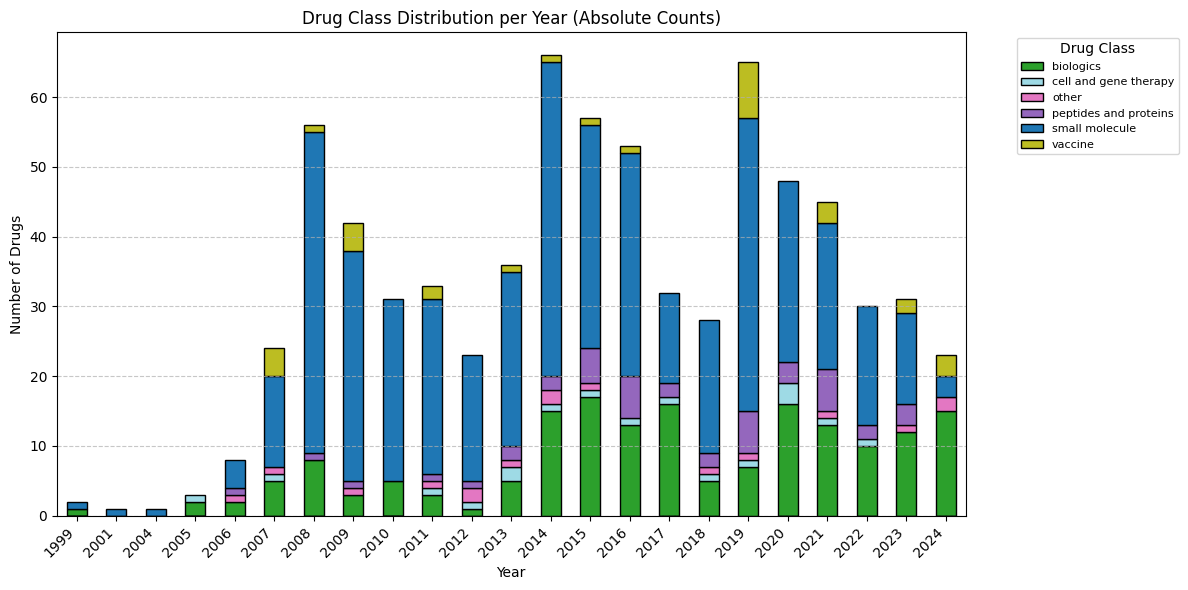

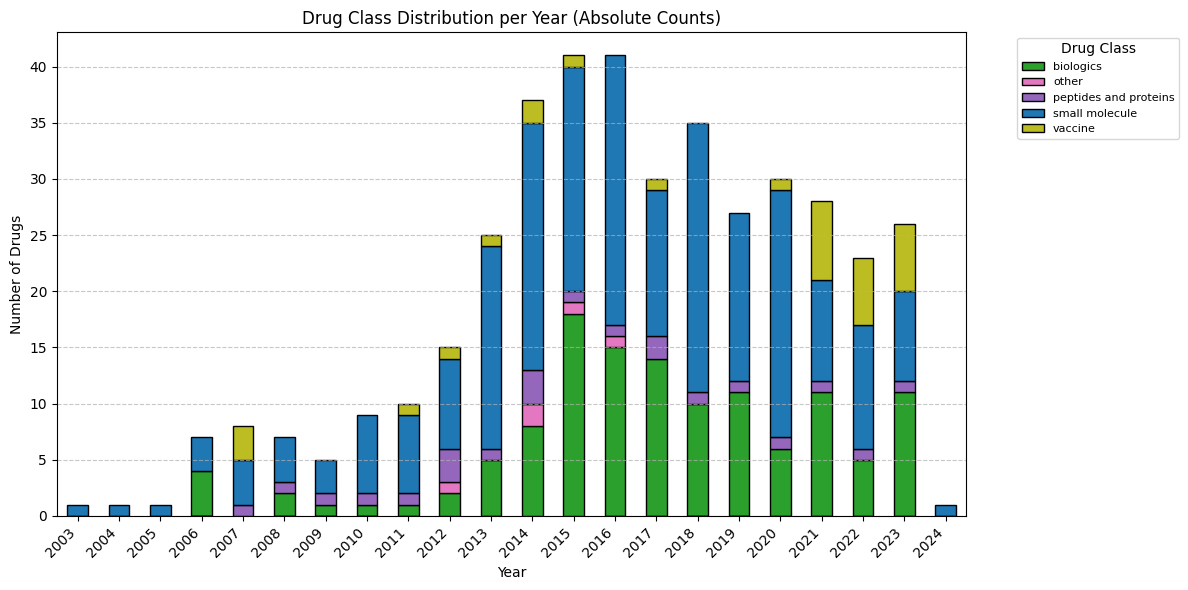

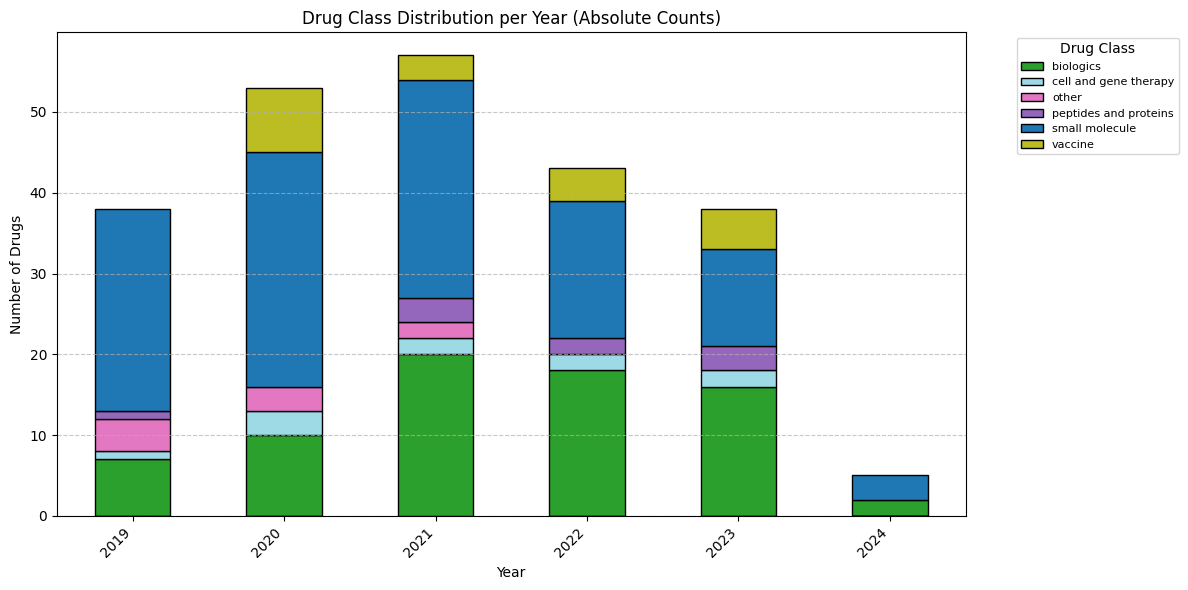

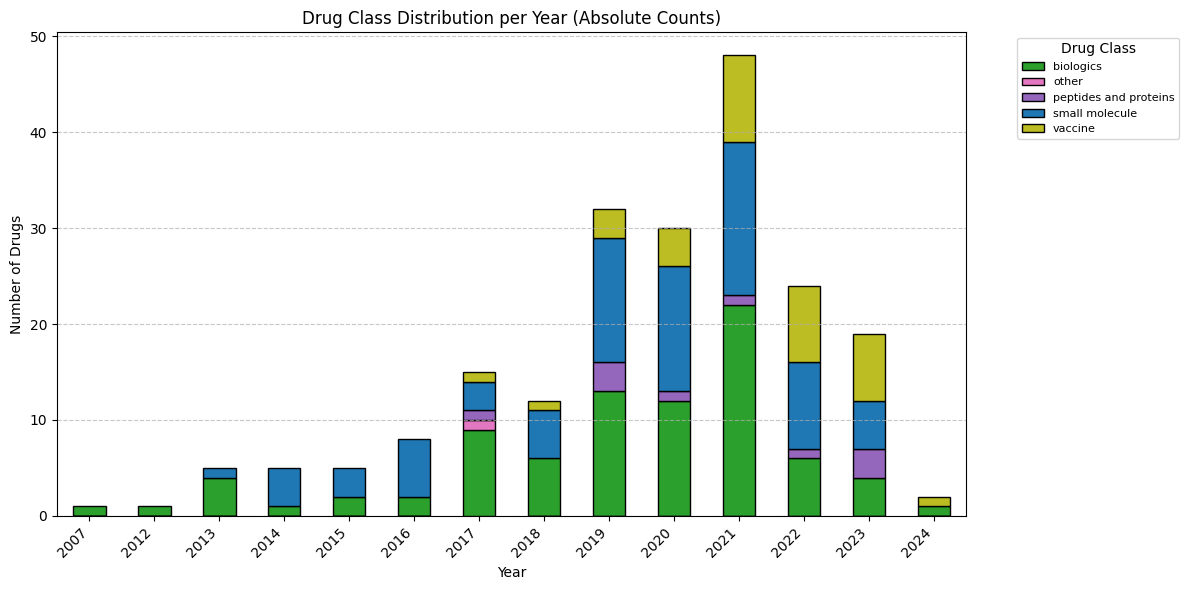

In [146]:

for k,v in DATASETS.items():
    if 'Application_year' in v.columns:
        plot_drug_class_per_application_year_absolute(v, drug_class_colormap=drug_class_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Application_year' column not found, skipping drug class plot.")


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1687, Final length after cleaning: 1687, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


...

Original length: 1049, Final length after cleaning: 1042, Percentage kept: 99.33%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 11523, Final length after cleaning: 11523, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 4978, Final length after cleaning: 4978, Percentage kept: 100.00%


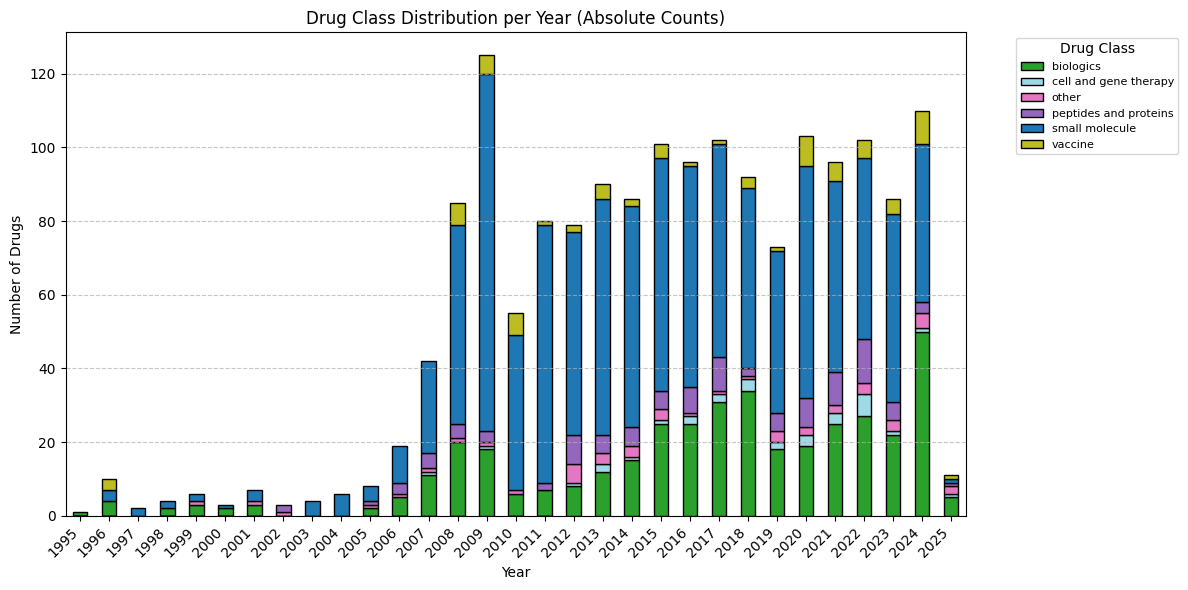

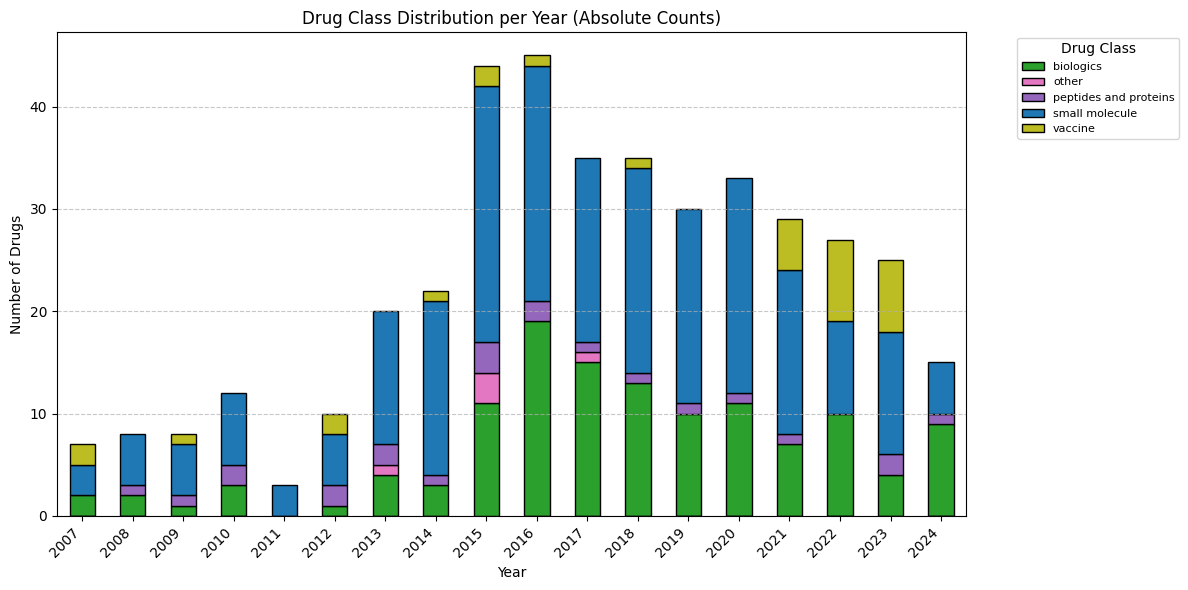

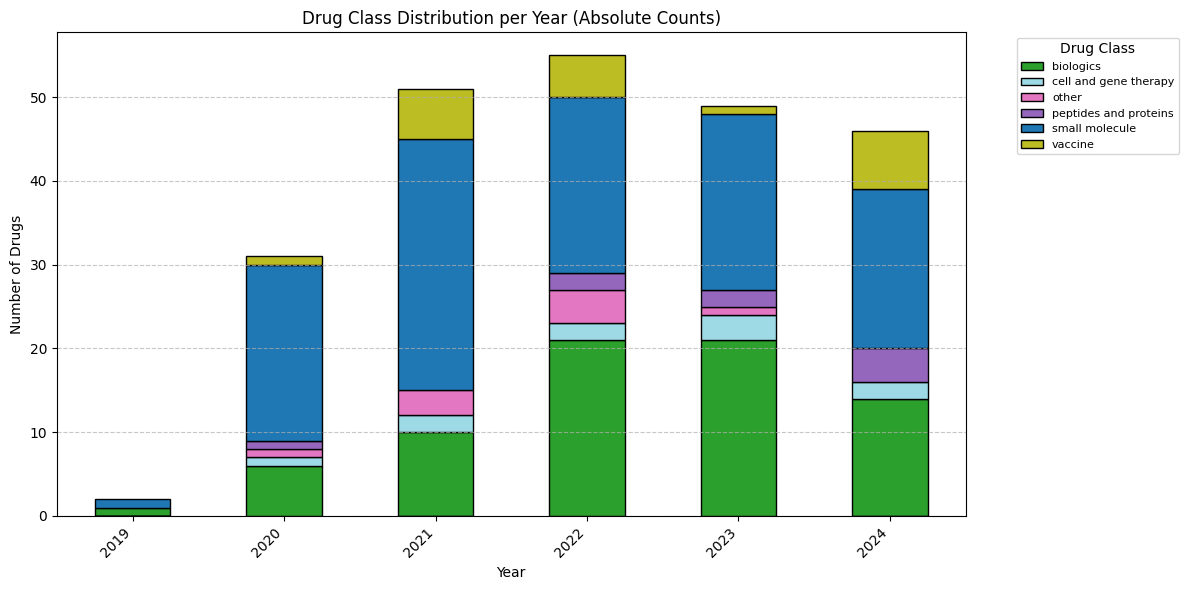

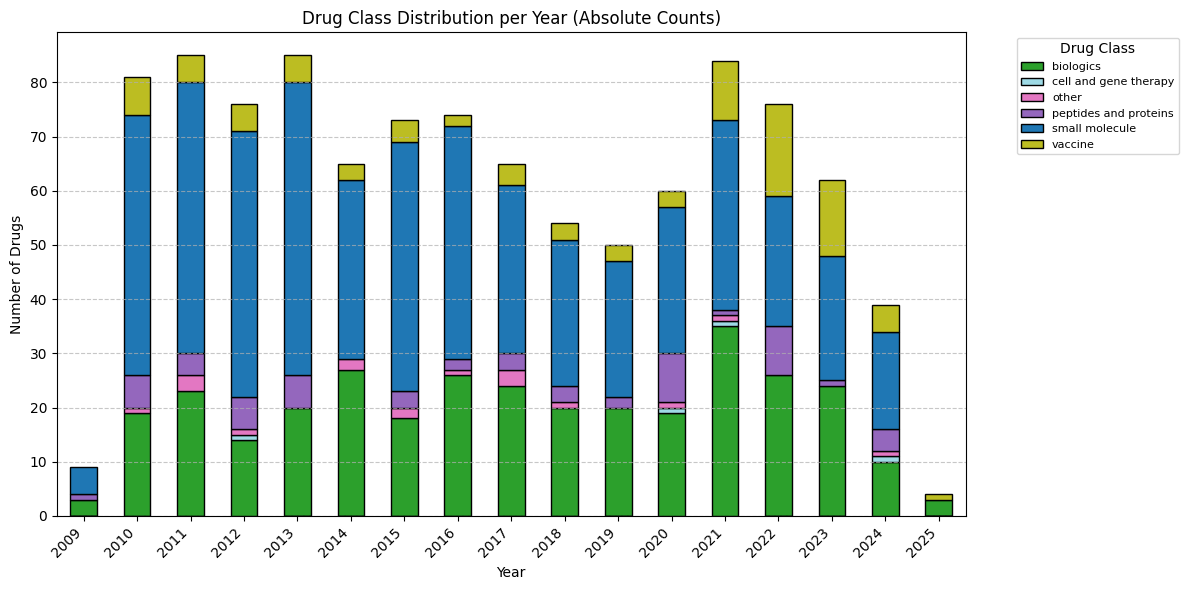

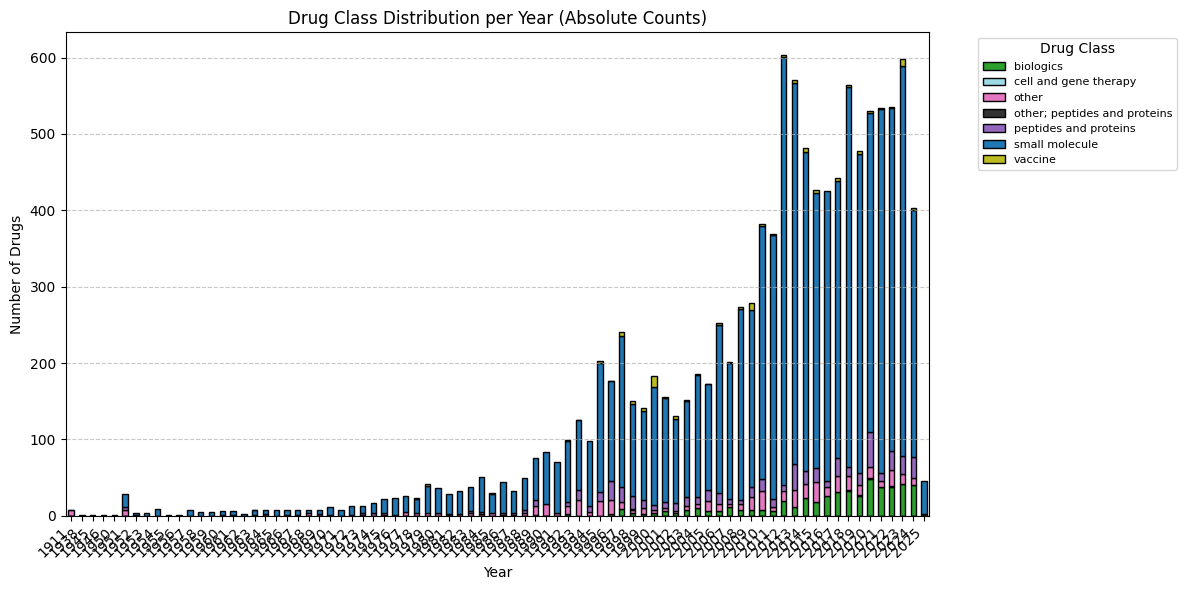

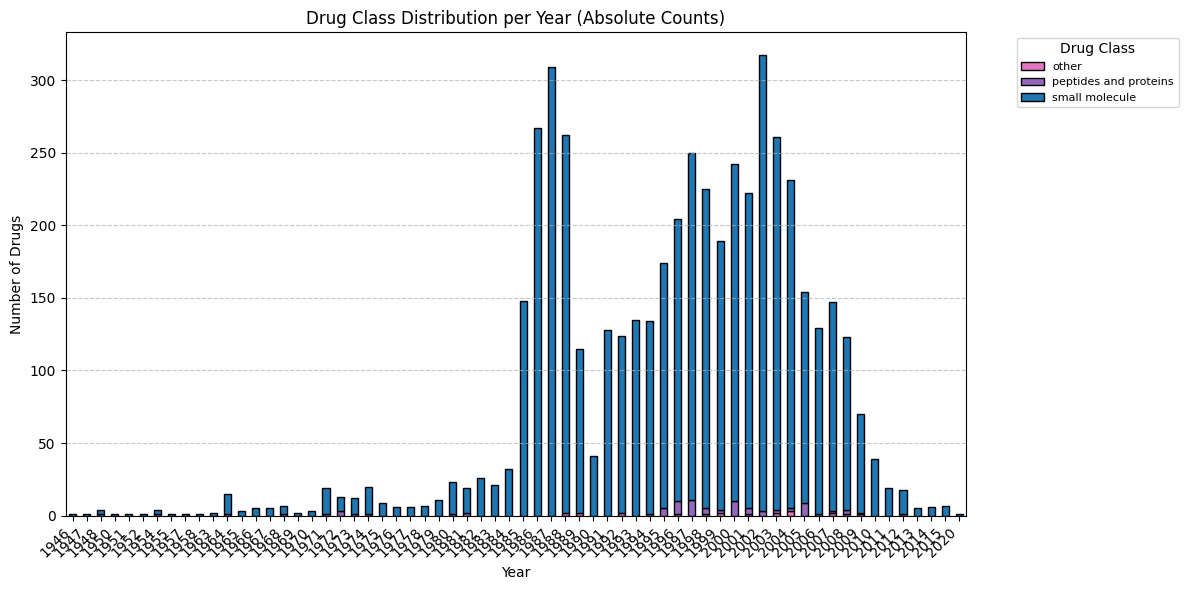

In [147]:
for k,v in DATASETS.items():
    if 'Decision_year' in v.columns:
        plot_drug_class_per_decision_year_absolute(v, drug_class_colormap=drug_class_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Decision_year' column not found, skipping drug class plot.")

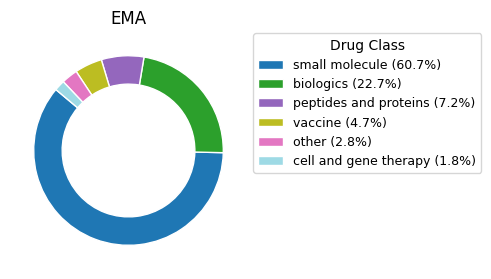

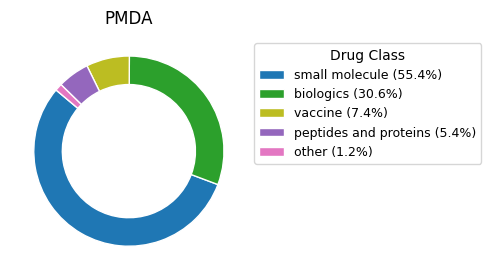

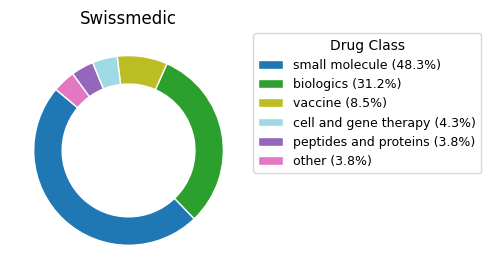

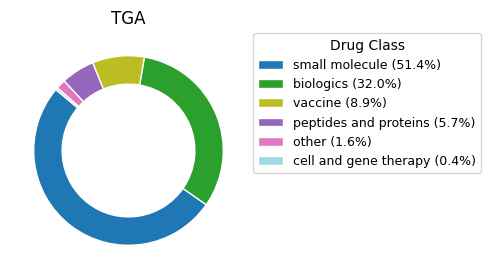

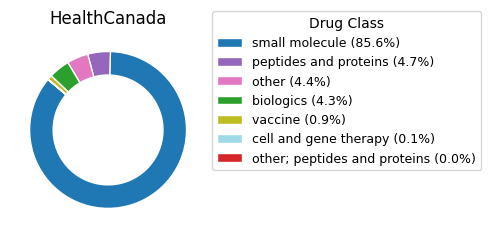

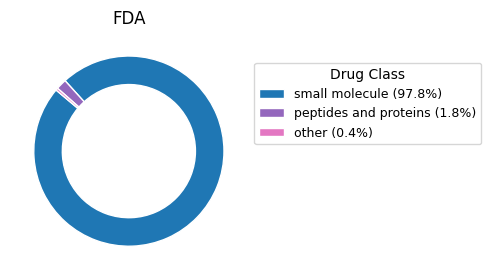

In [148]:
for k,v in DATASETS.items():
    if 'Drug_class' in v.columns:
        plot_drug_class_distribution_pie(v, drug_class_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Drug_class' column not found, skipping drug class distribution pie chart.")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1687, Final length after cleaning: 1687, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


...

Original length: 1049, Final length after cleaning: 1042, Percentage kept: 99.33%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 11523, Final length after cleaning: 11523, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 4978, Final length after cleaning: 4978, Percentage kept: 100.00%


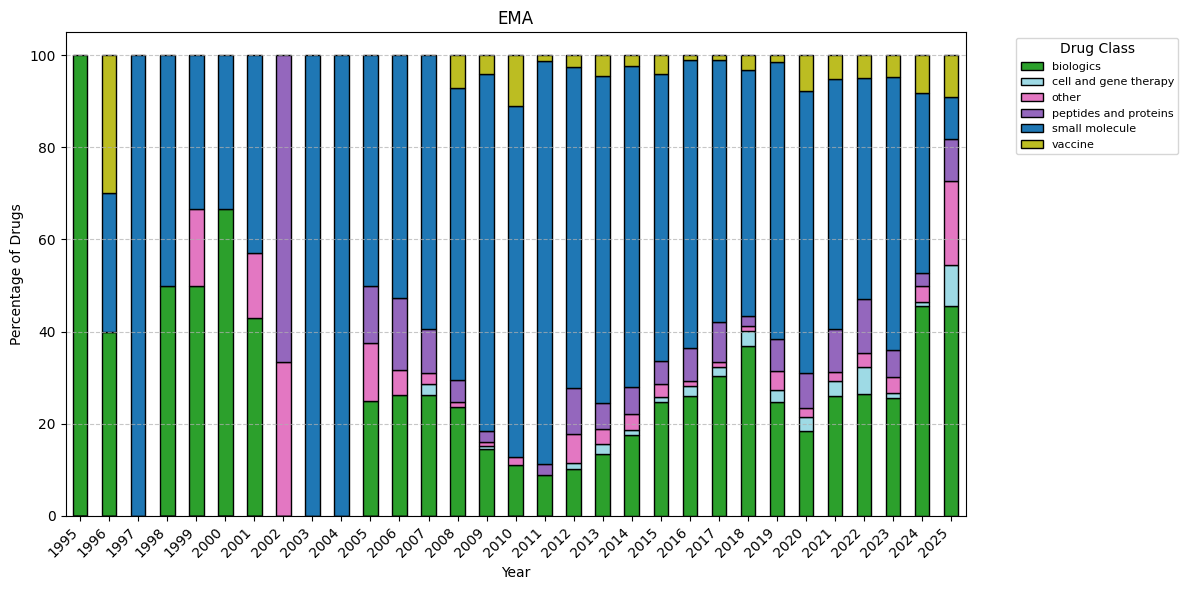

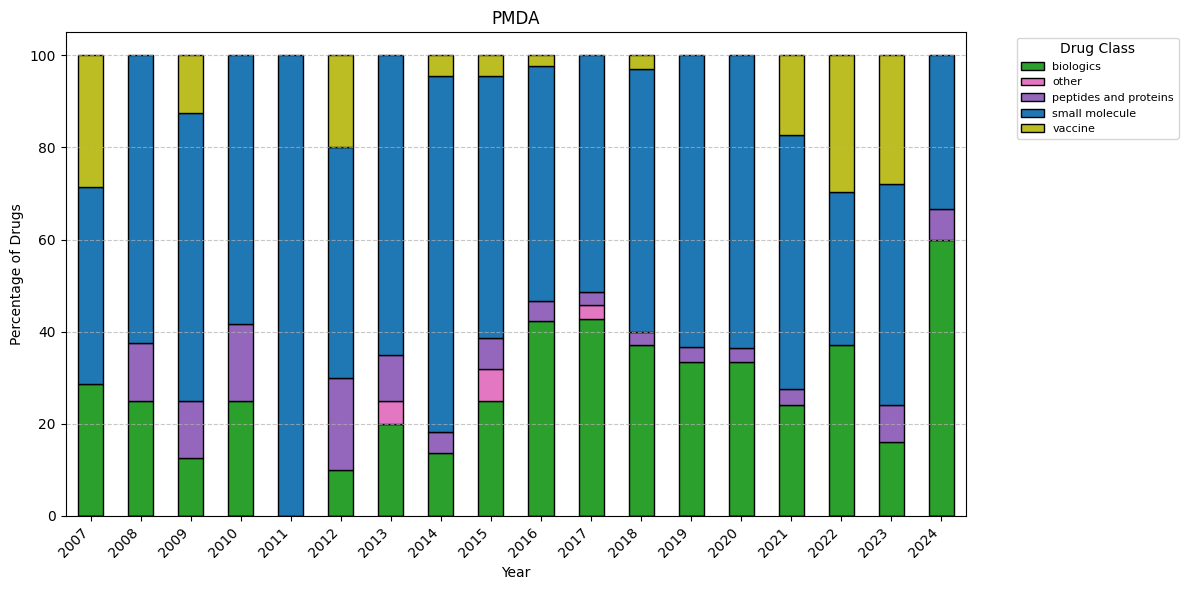

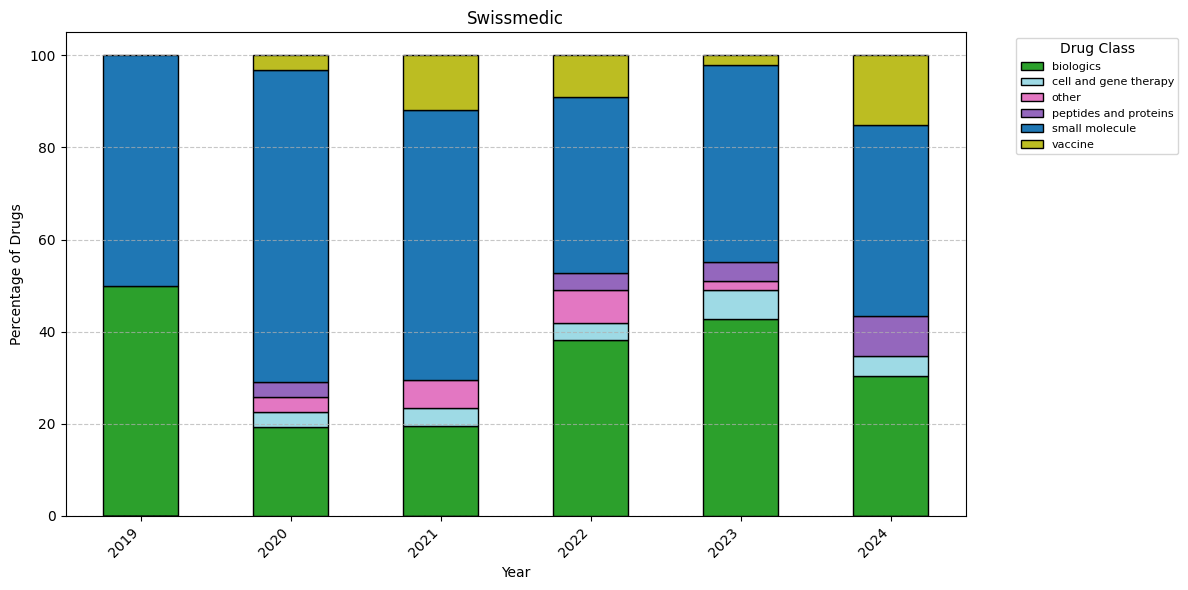

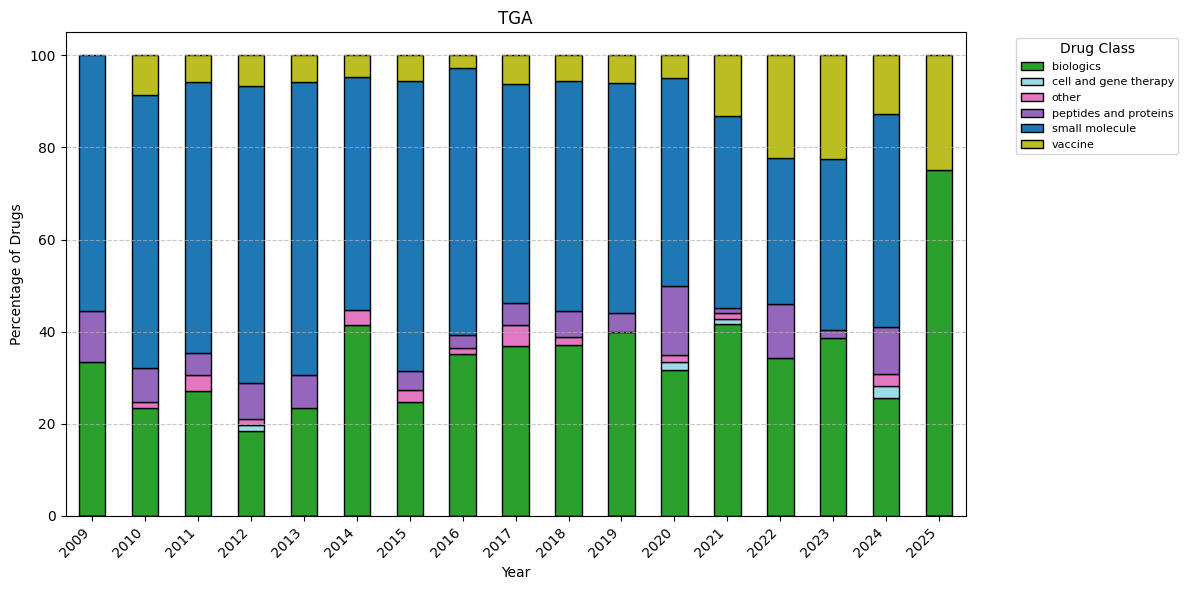

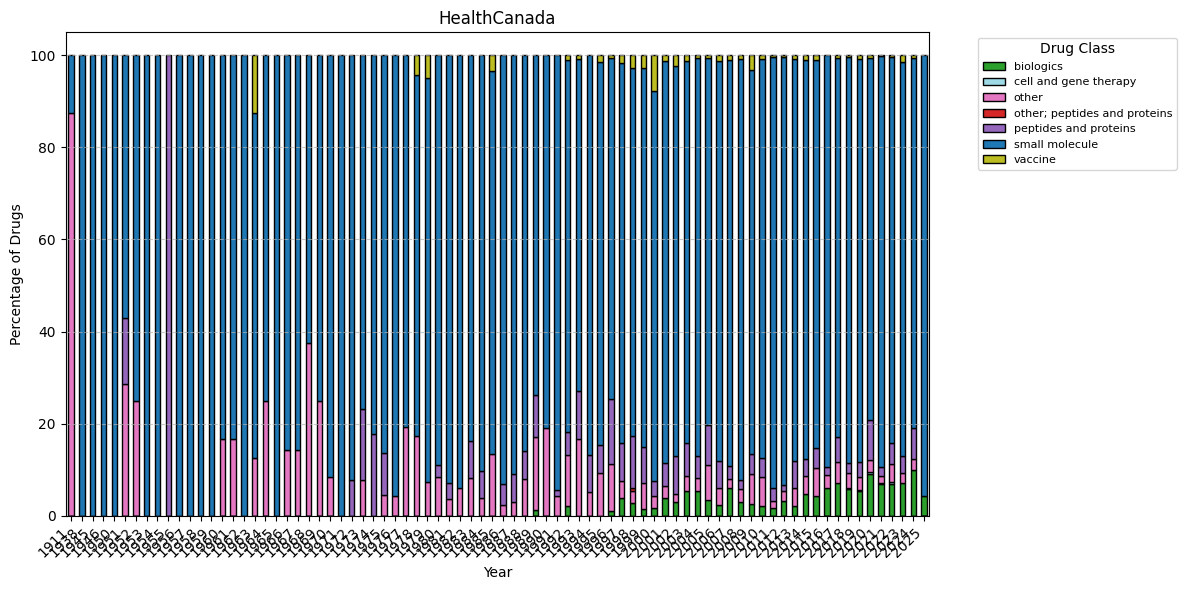

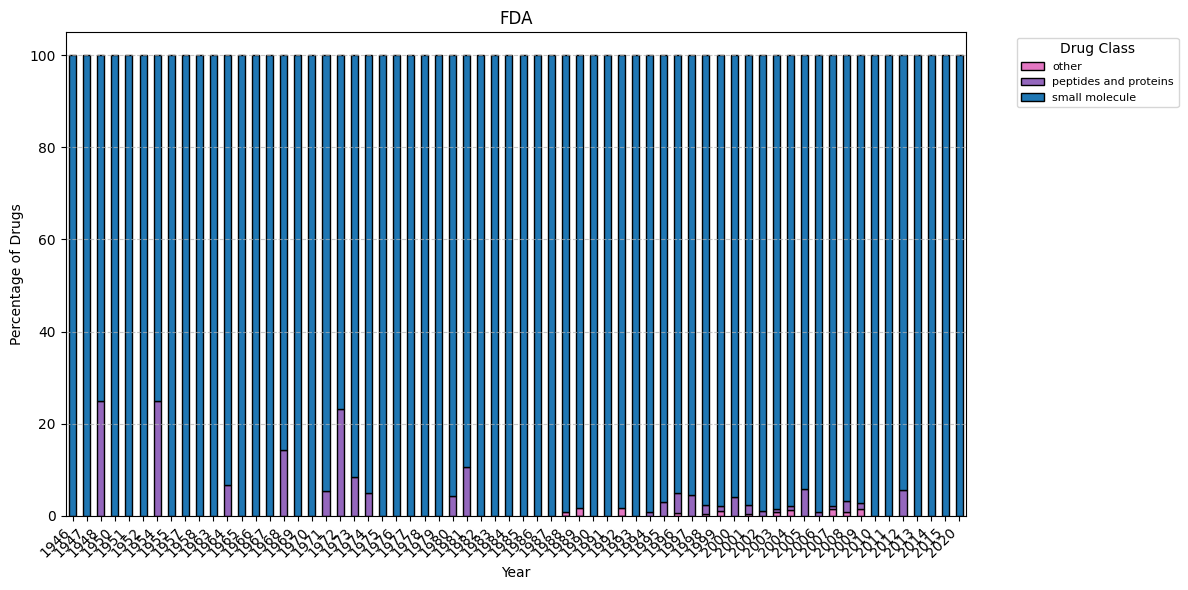

In [149]:
for k,v in DATASETS.items():
    if 'Decision_year' in v.columns:
        plot_drug_class_per_year(v, date_col='Decision_year', drug_class_colormap=drug_class_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Decision_year' column not found, skipping disease class per decision year plot.")

In [150]:
# skipping for now, too messy and not useful

# for k,v in DATASETS.items():
#     if 'Administration_route' in v.columns:
#         plot_drug_class_by_administration_route(v, dataset_name=k)
#     else:
#         print(f"{k}: 'Administration_route' column not found, skipping drug class by administration route plot.")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:294: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:294: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:294: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:325: UserWarning: Tight layout not applied. T

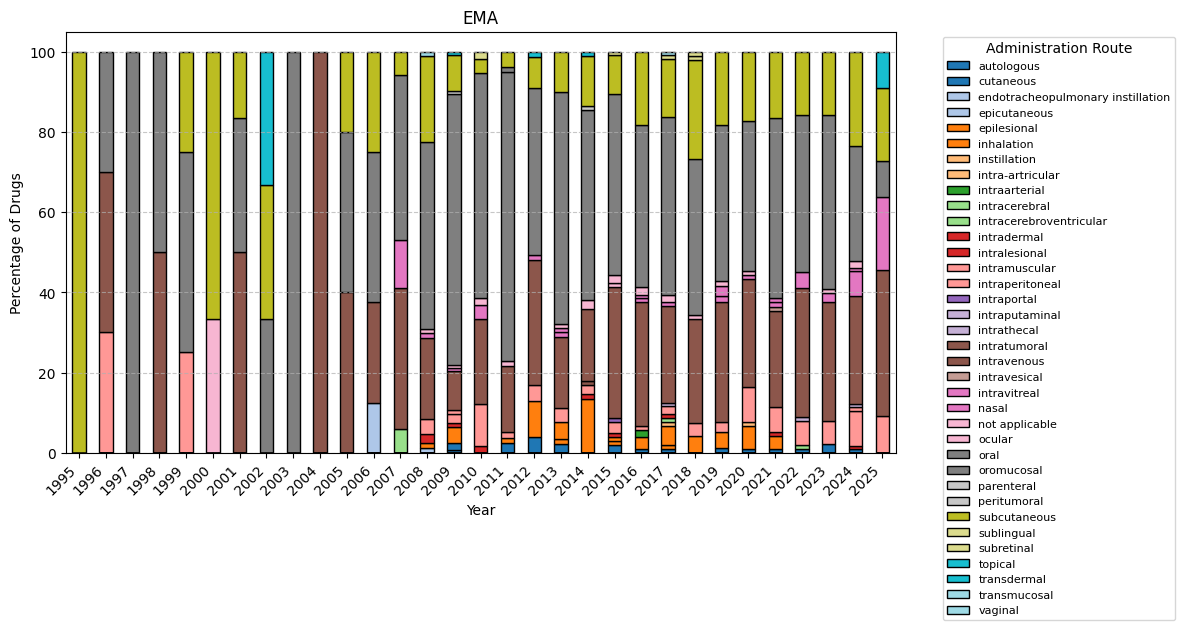

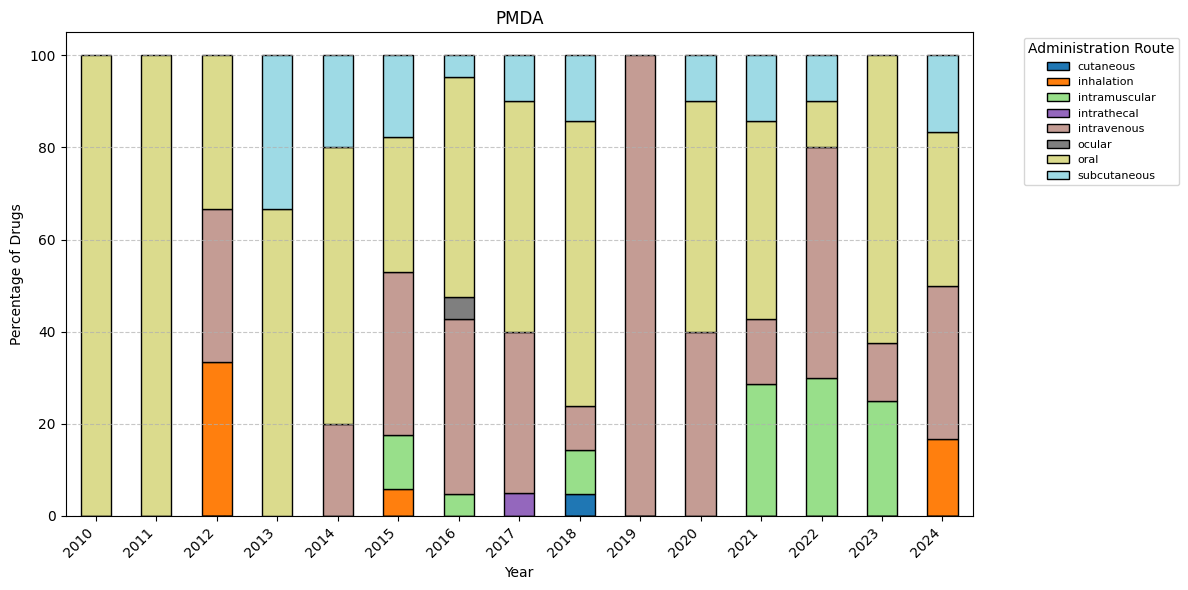

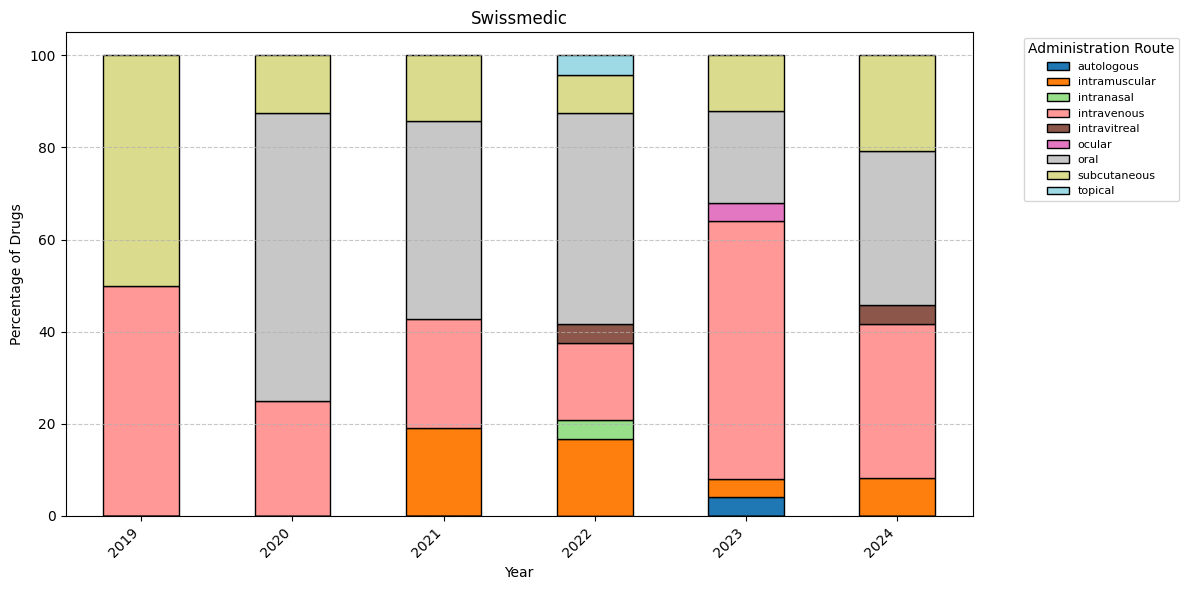

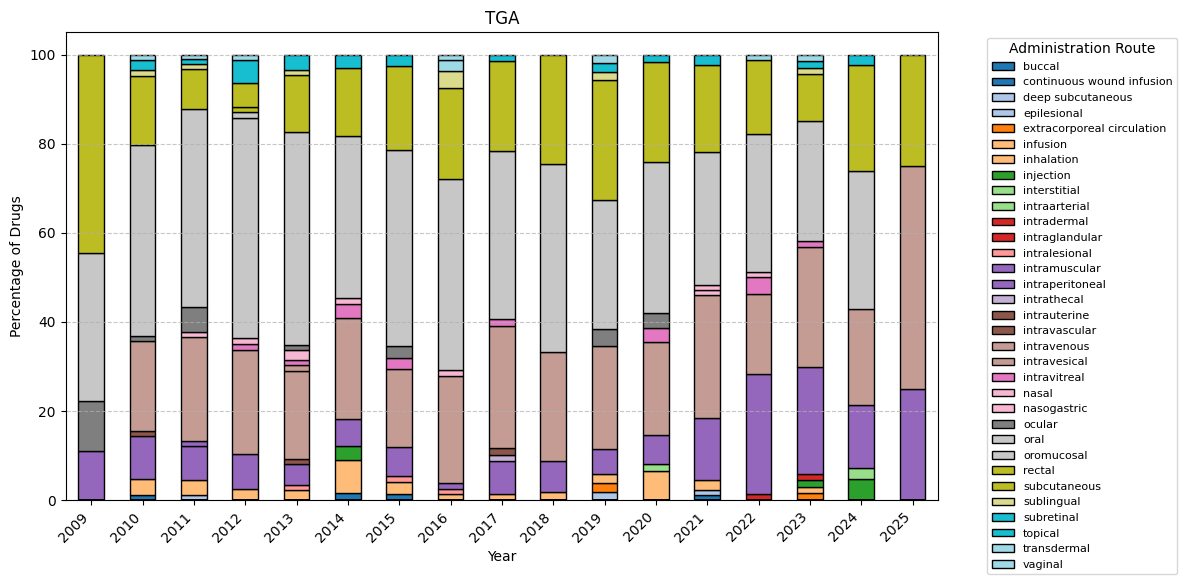

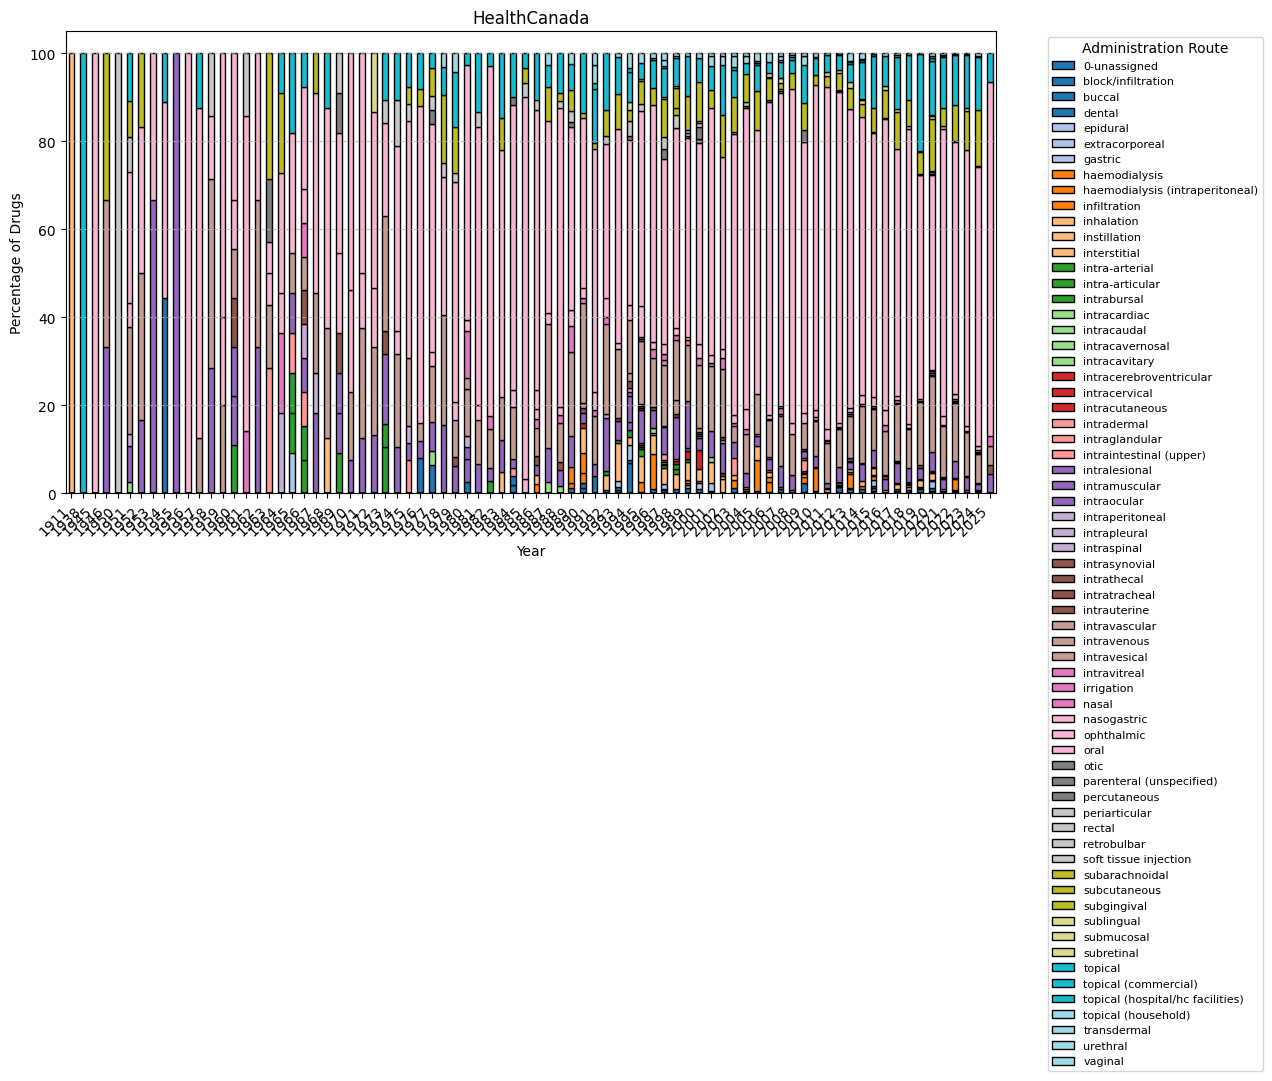

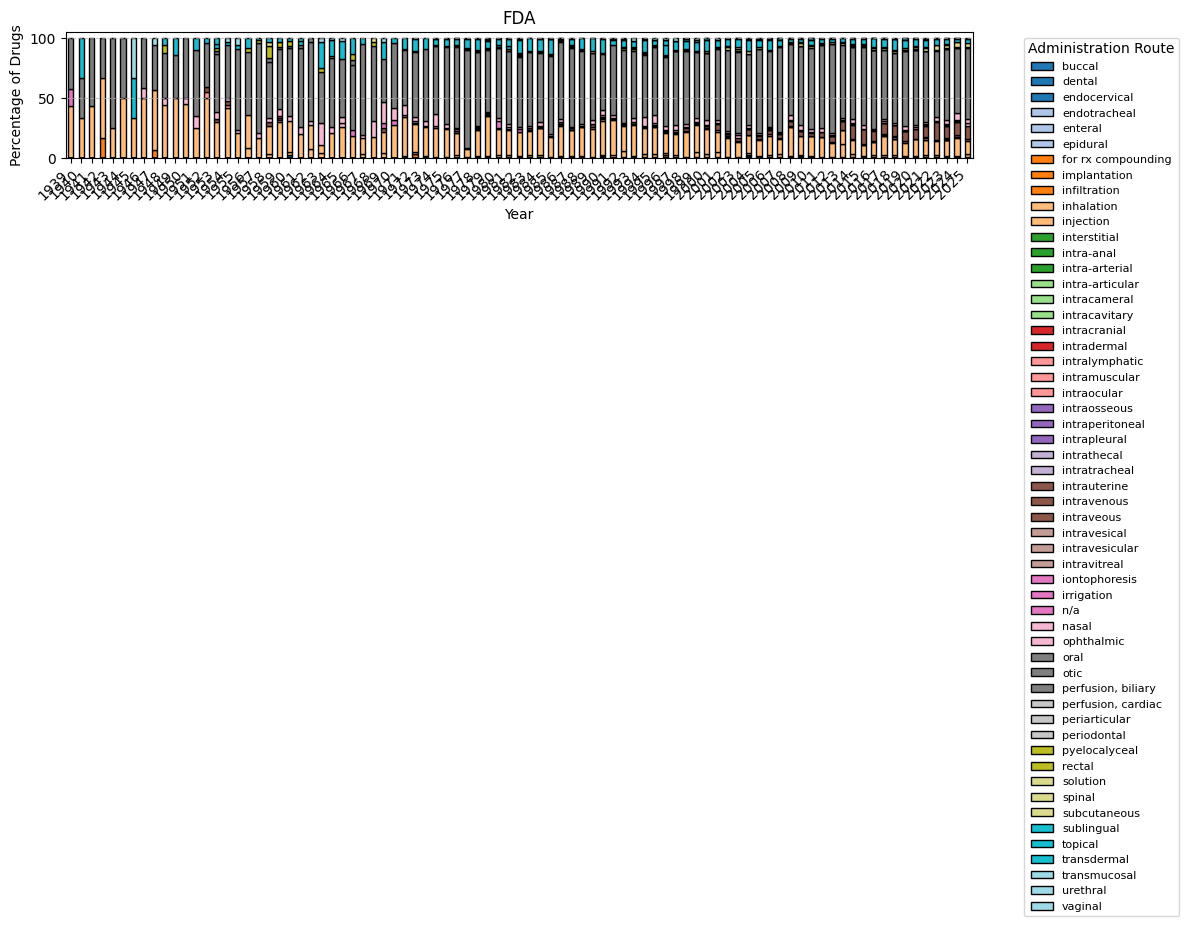

In [151]:
for k,v in DATASETS.items():
    if "Decision_date" in v.columns:
        plot_administration_route_per_year(v, agency_name=k, date_col='Decision_date', dataset_name=k)
    else:
        print(f"{k}: 'Decision_date' column not found, skipping administration route per year plot.")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)
C:\Users\hh25g55

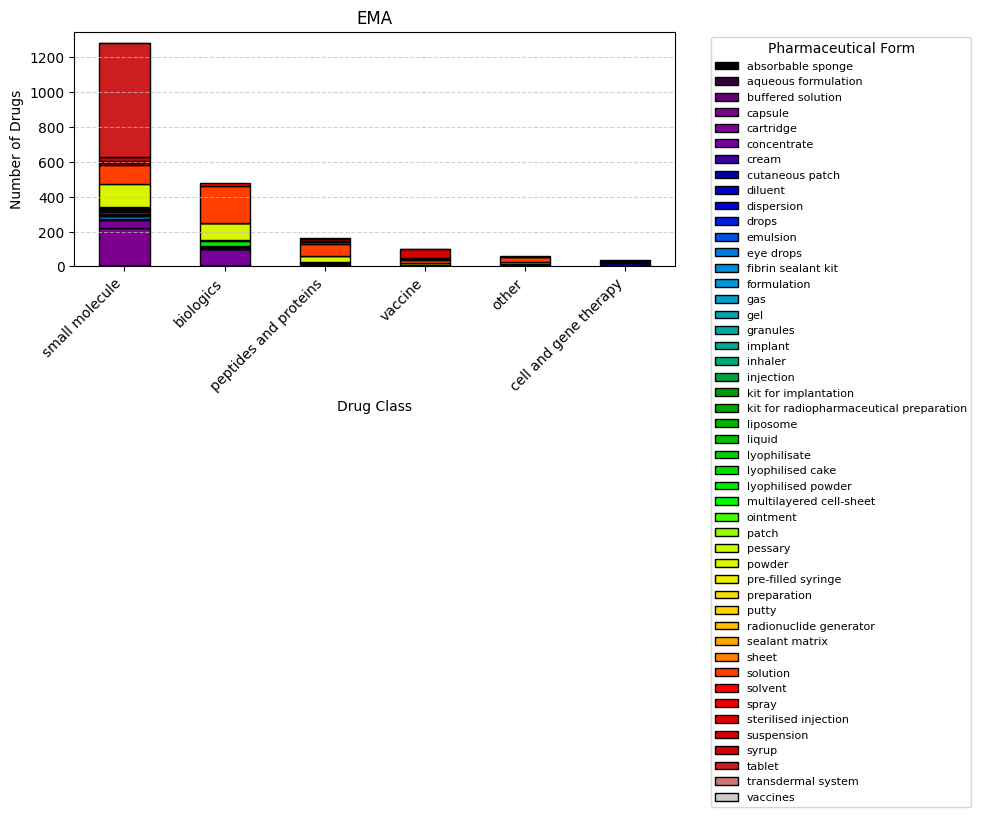

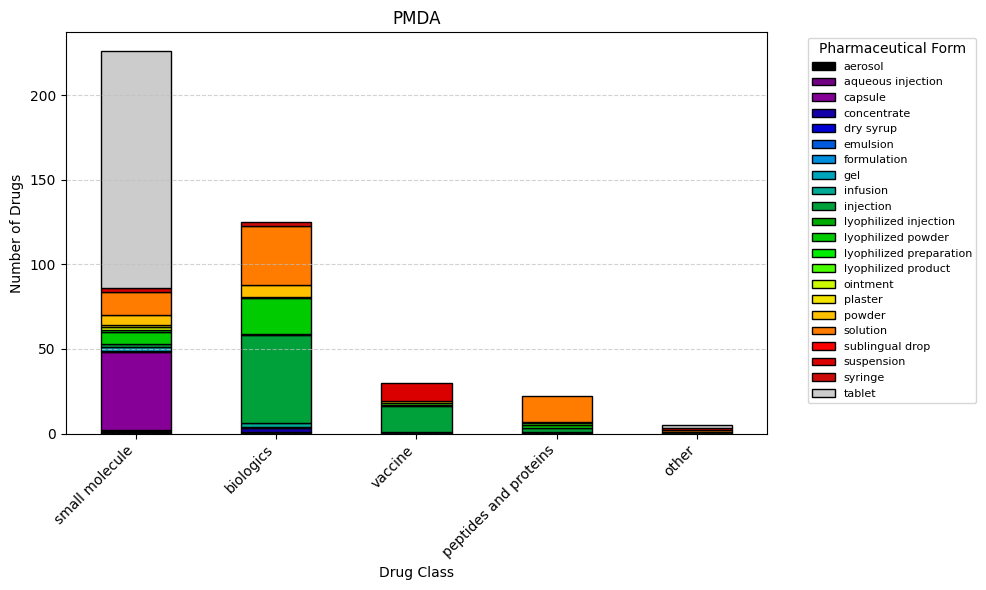

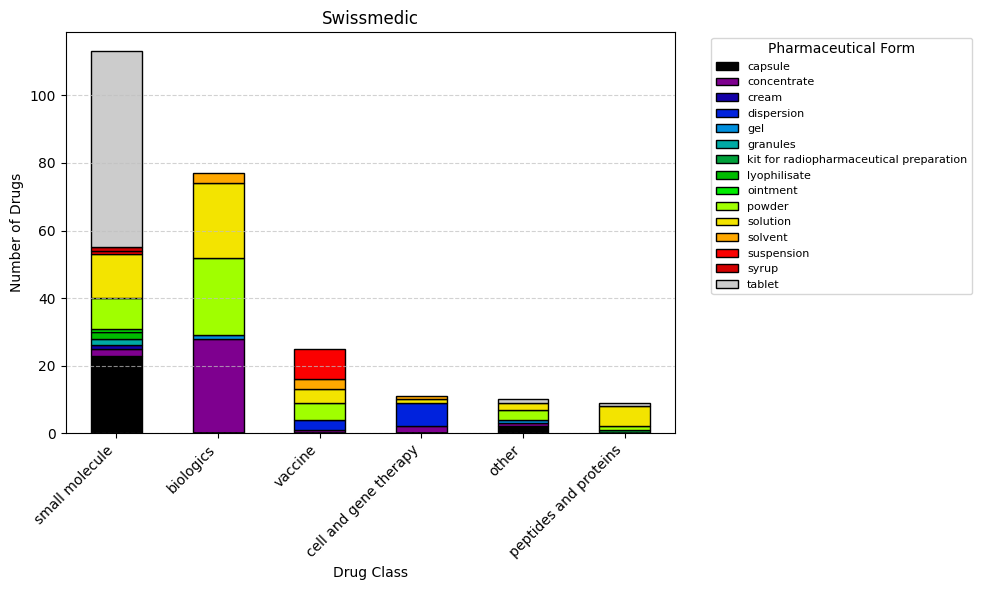

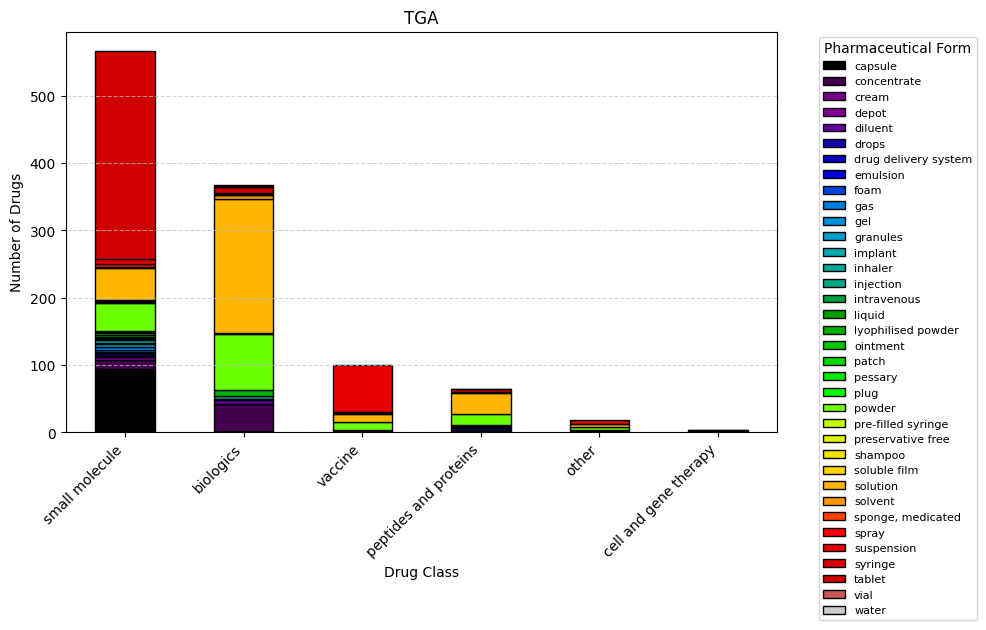

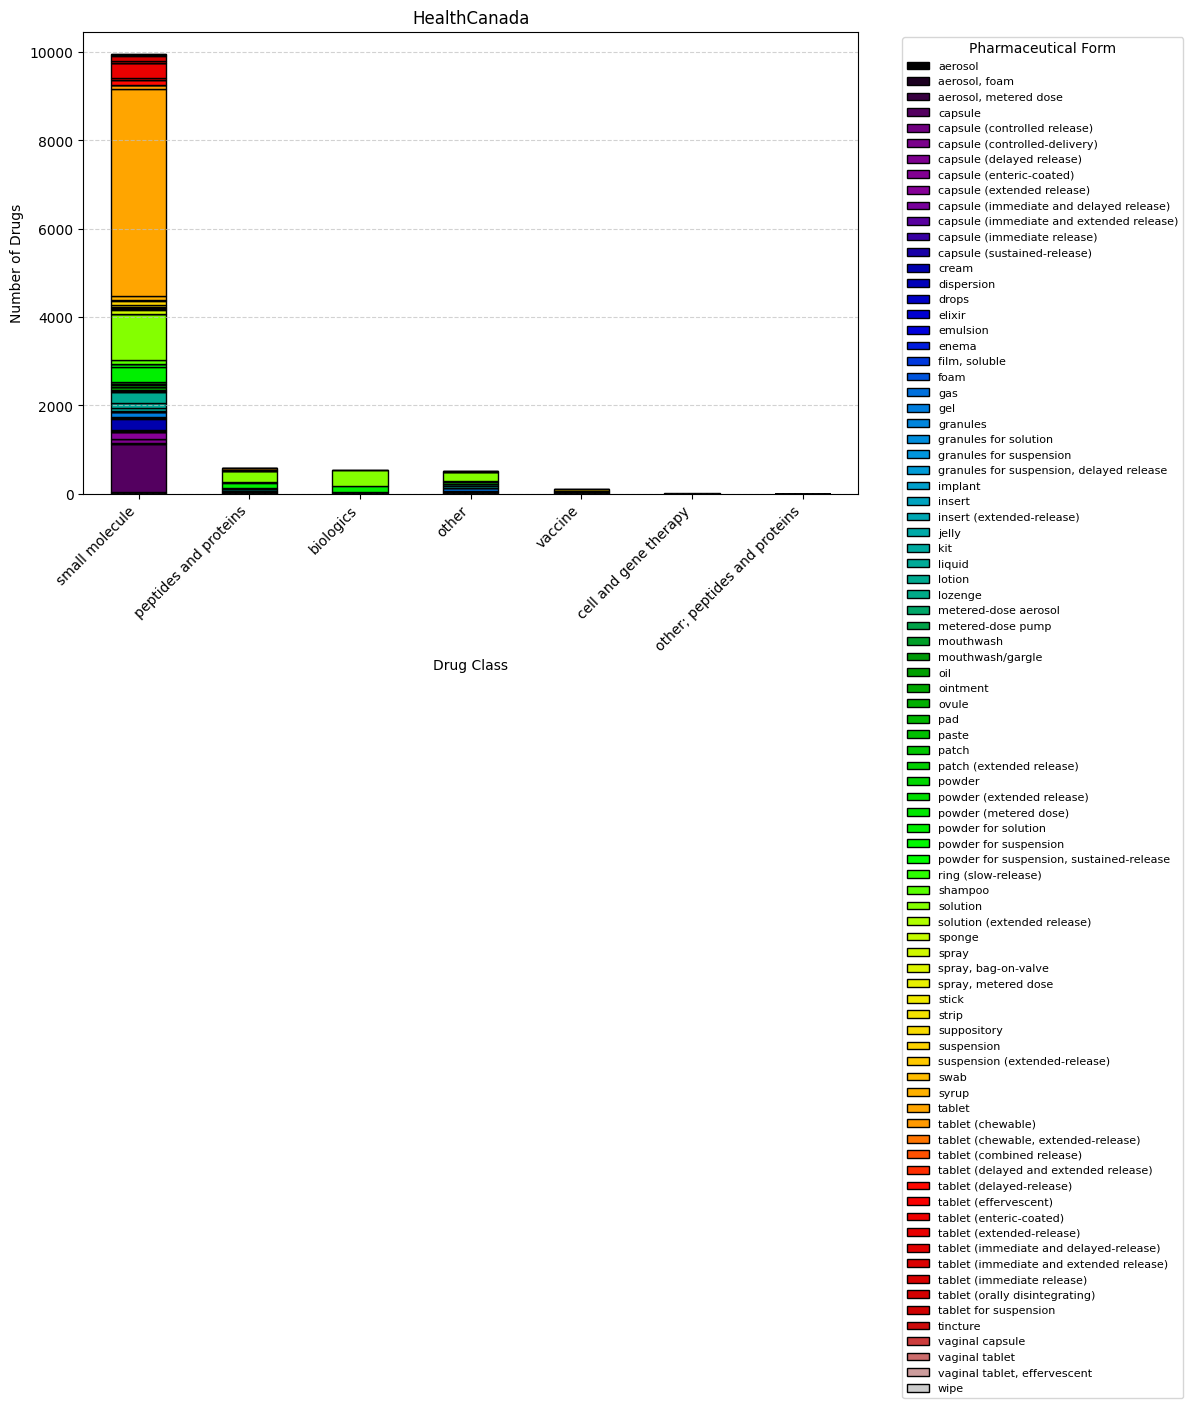

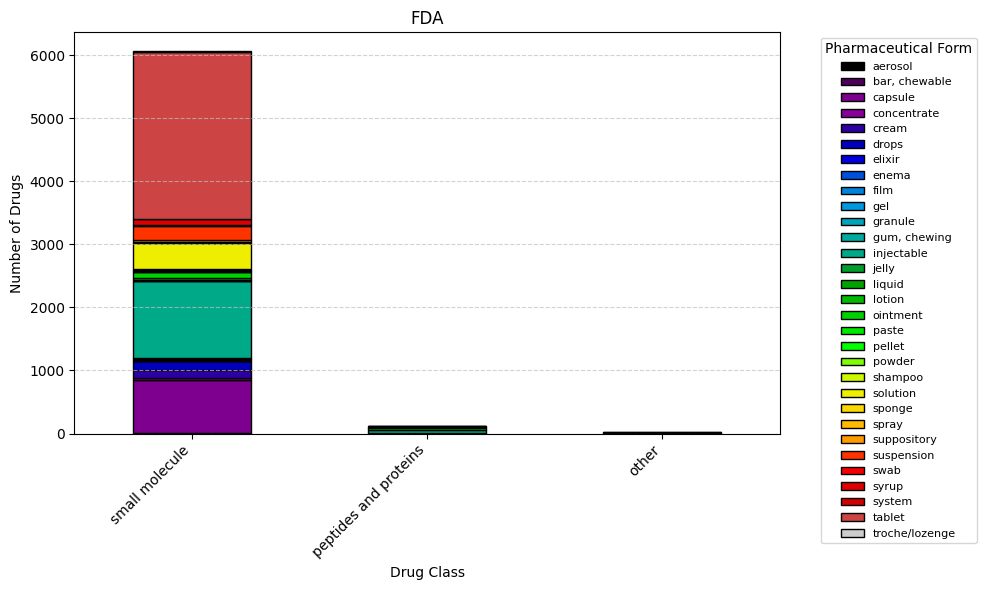

In [152]:
for k,v in DATASETS.items():
    if 'Pharmaceutical_form' in v.columns:
        plot_drug_class_by_pharmaceutical_form(v, dataset_name=k)
    else:
        print(f"{k}: 'Pharmaceutical_form' column not found, skipping drug class by pharmaceutical form plot.")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:377: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_3

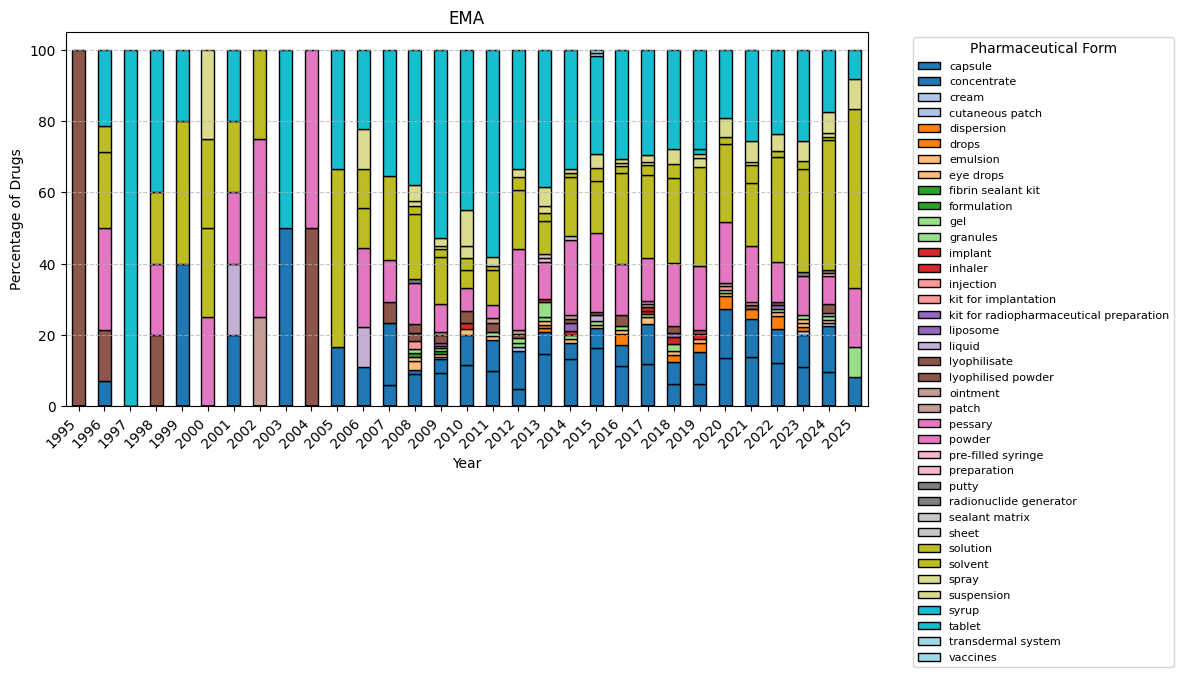

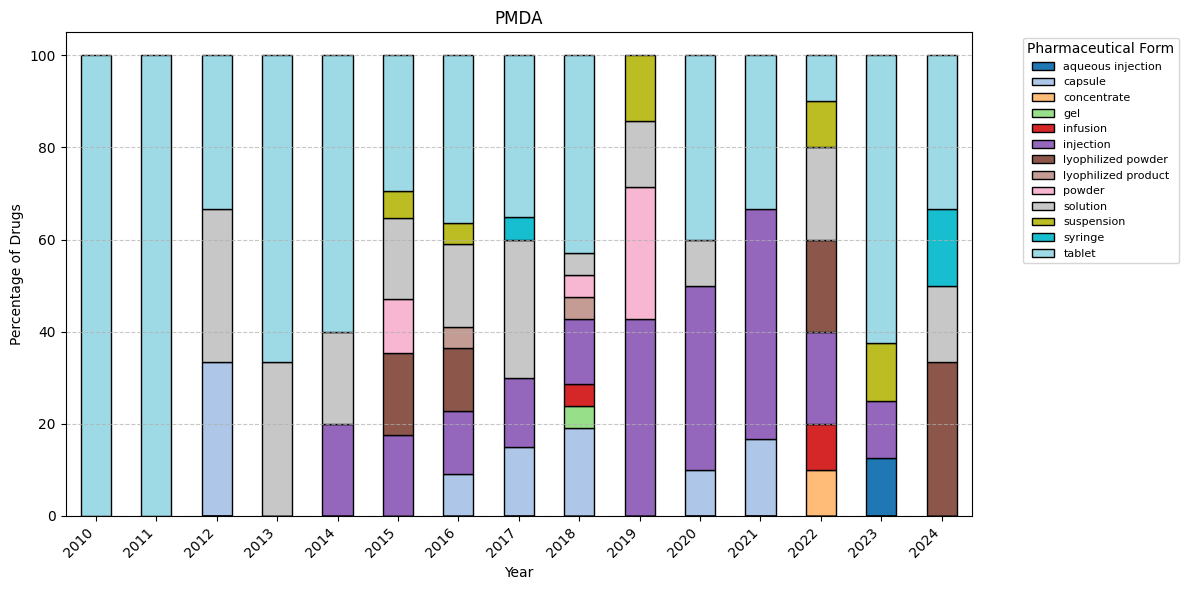

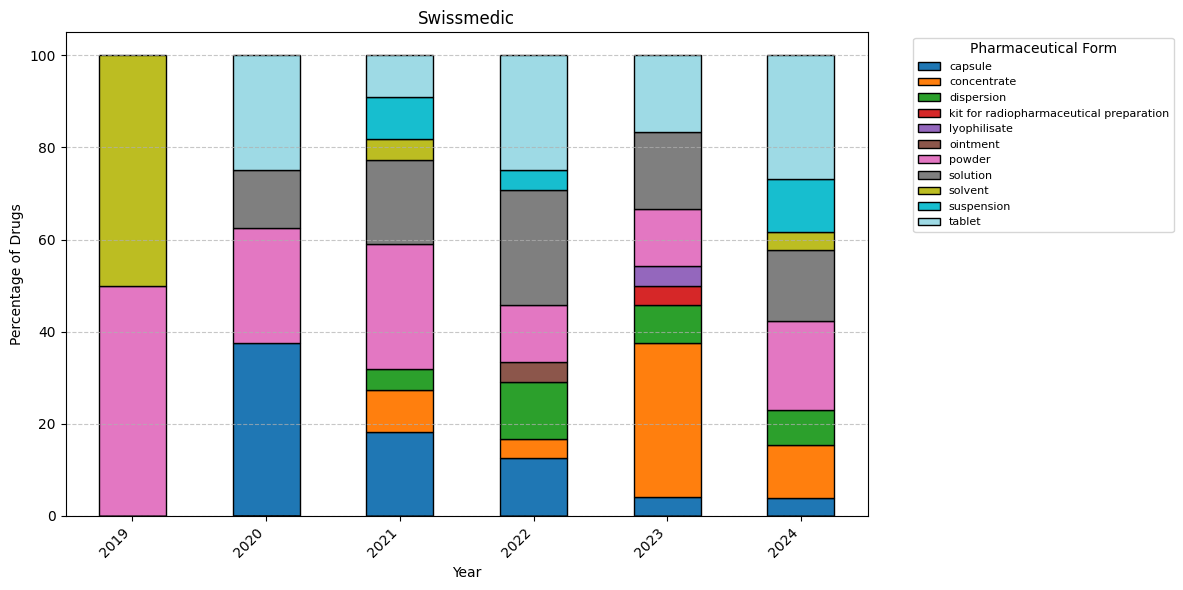

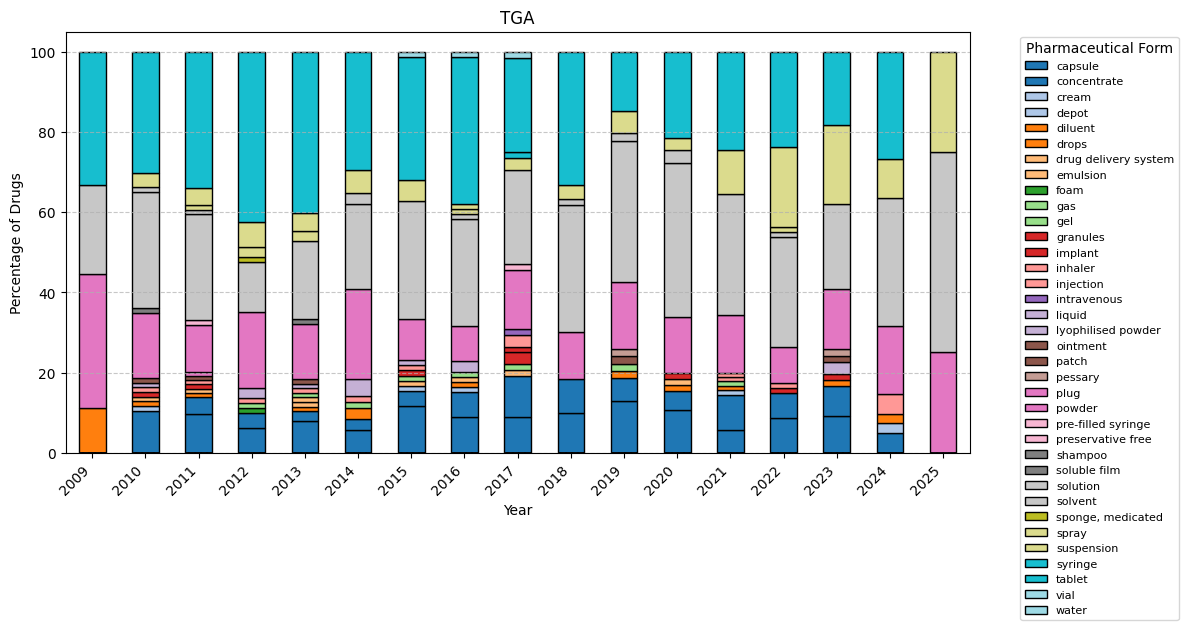

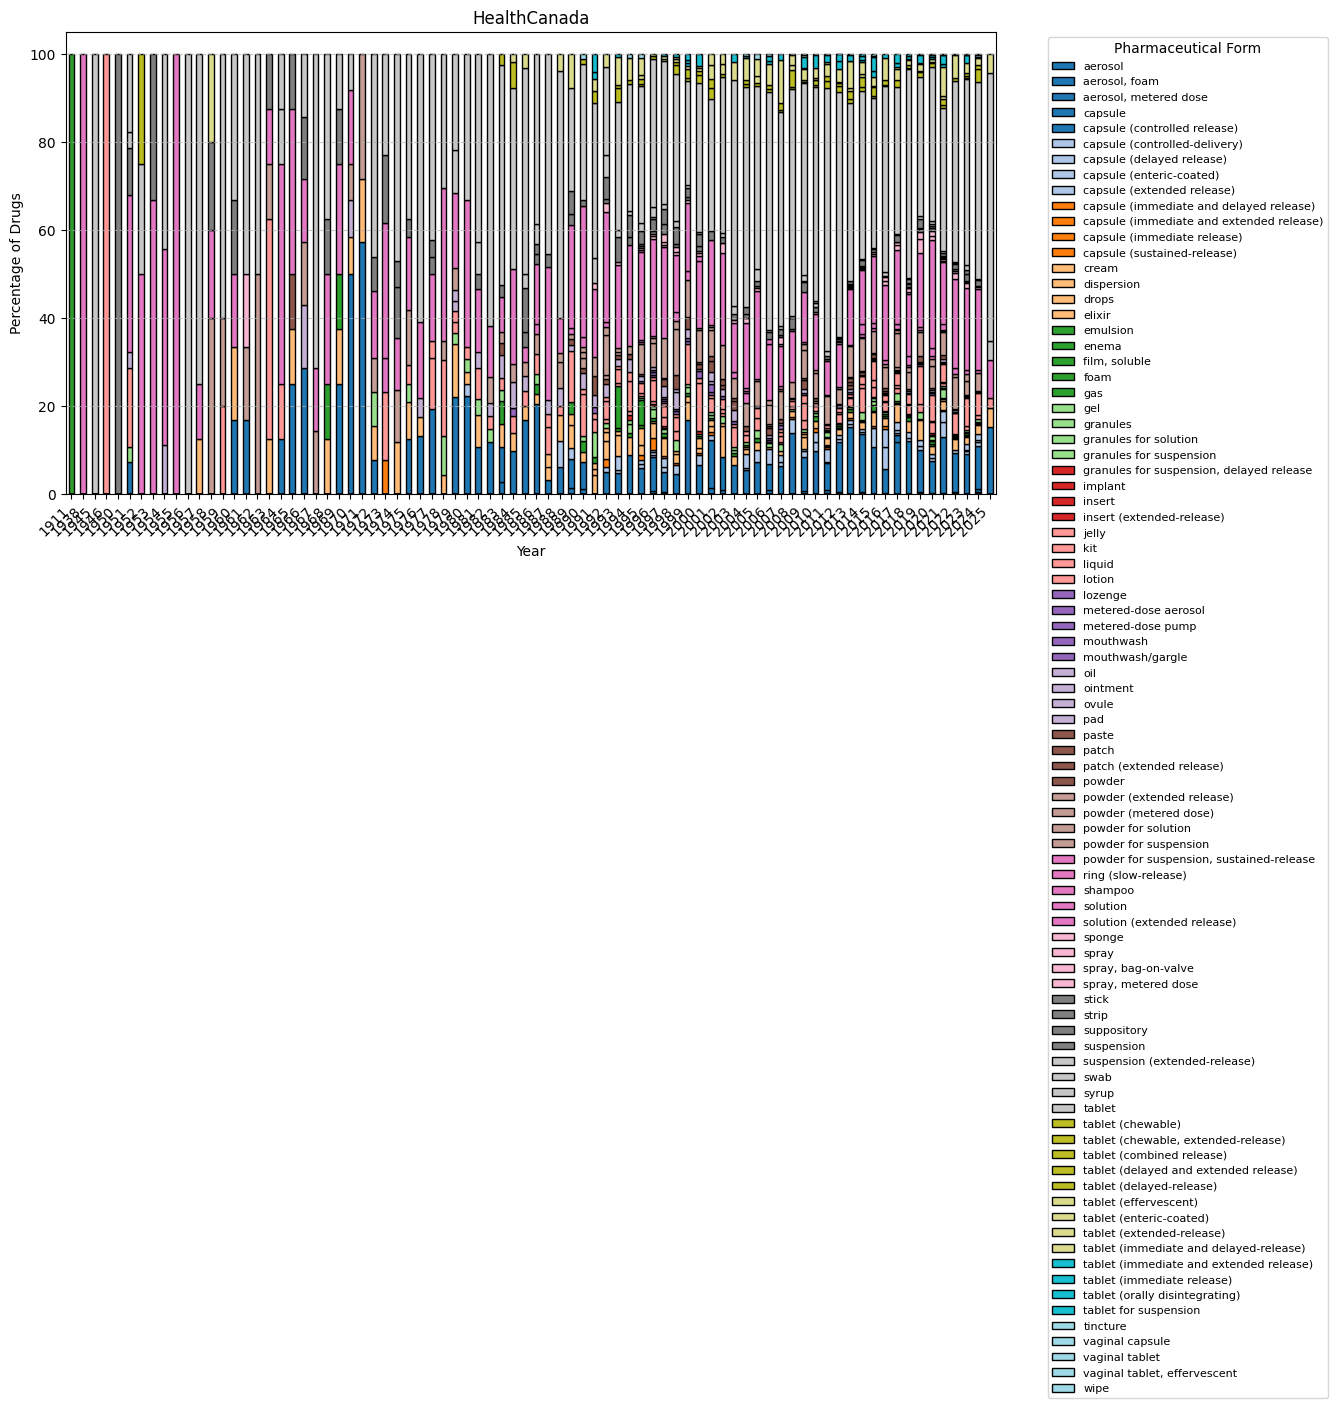

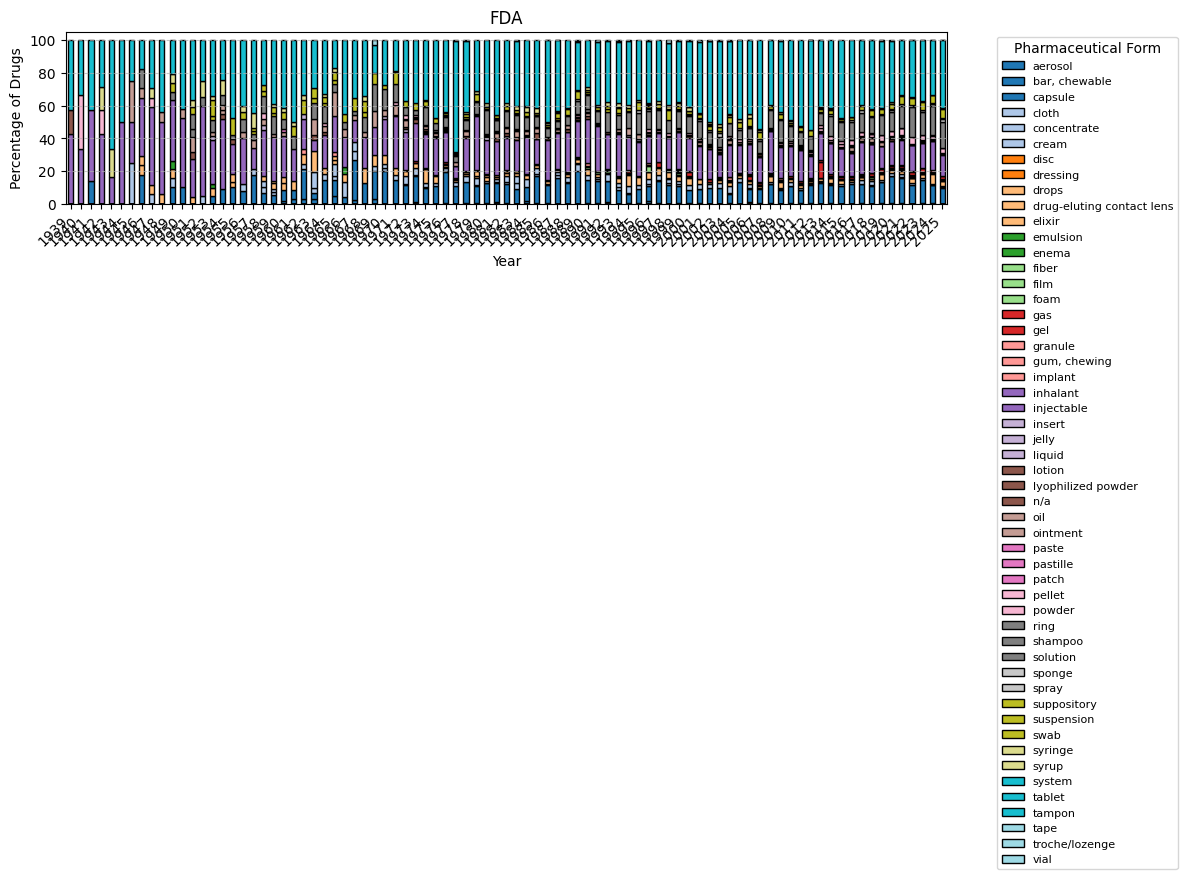

In [153]:
for k,v in DATASETS.items():
    if "Decision_date" in v.columns:
        plot_pharmaceutical_form_per_year(v, agency_name=k, date_col='Decision_date', dataset_name=k)
    else:
        print(f"{k}: 'Decision_date' column not found, skipping pharmaceutical form per year plot.")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)


Original length: 1687, Final length after cleaning: 1687, Percentage kept: 100.00%

Top 2 Disease Classes (absolute Häufigkeit):
neoplasms: 479
diseases of the blood and blood-forming organs: 288


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)


Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%

Top 2 Disease Classes (absolute Häufigkeit):
neoplasms: 129
infectious and parasitic diseases: 79


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)


Original length: 234, Final length after cleaning: 234, Percentage kept: 100.00%

Top 2 Disease Classes (absolute Häufigkeit):
neoplasms: 73
diseases of the blood and blood-forming organs: 50


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)


Original length: 1049, Final length after cleaning: 1042, Percentage kept: 99.33%

Top 2 Disease Classes (absolute Häufigkeit):
neoplasms: 278
infectious and parasitic diseases: 182
HealthCanada: 'Decision_year' or 'Disease_class(es)' column not found, skipping disease class per decision year absolute plot.
Original length: 3438, Final length after cleaning: 3438, Percentage kept: 100.00%

Top 2 Disease Classes (absolute Häufigkeit):
diseases of the nervous system: 605
infectious and parasitic diseases: 588


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, n)


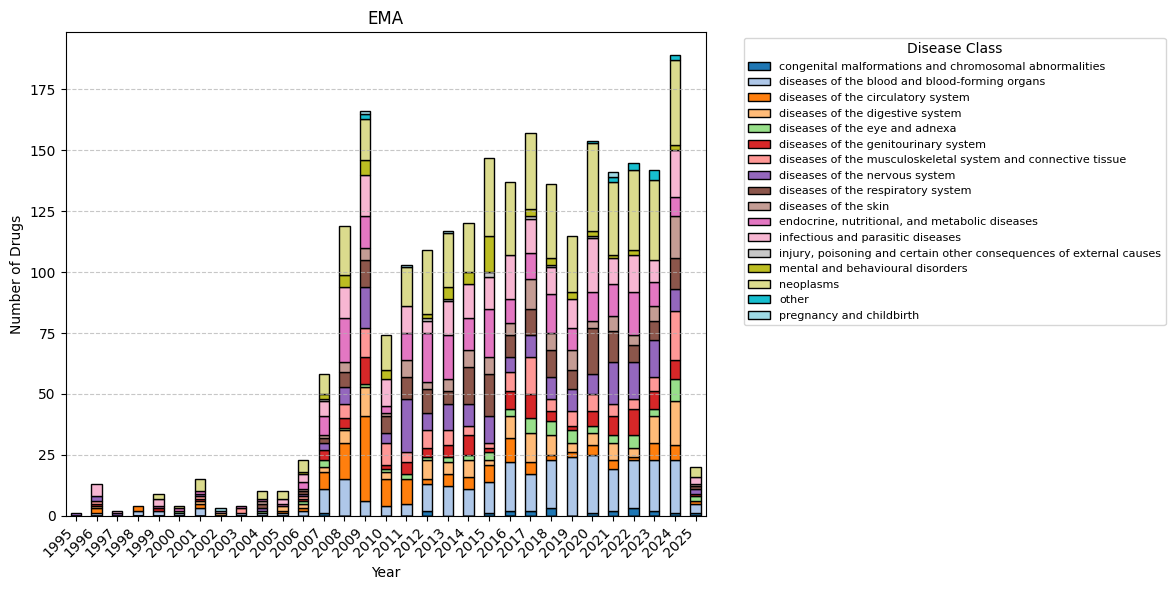

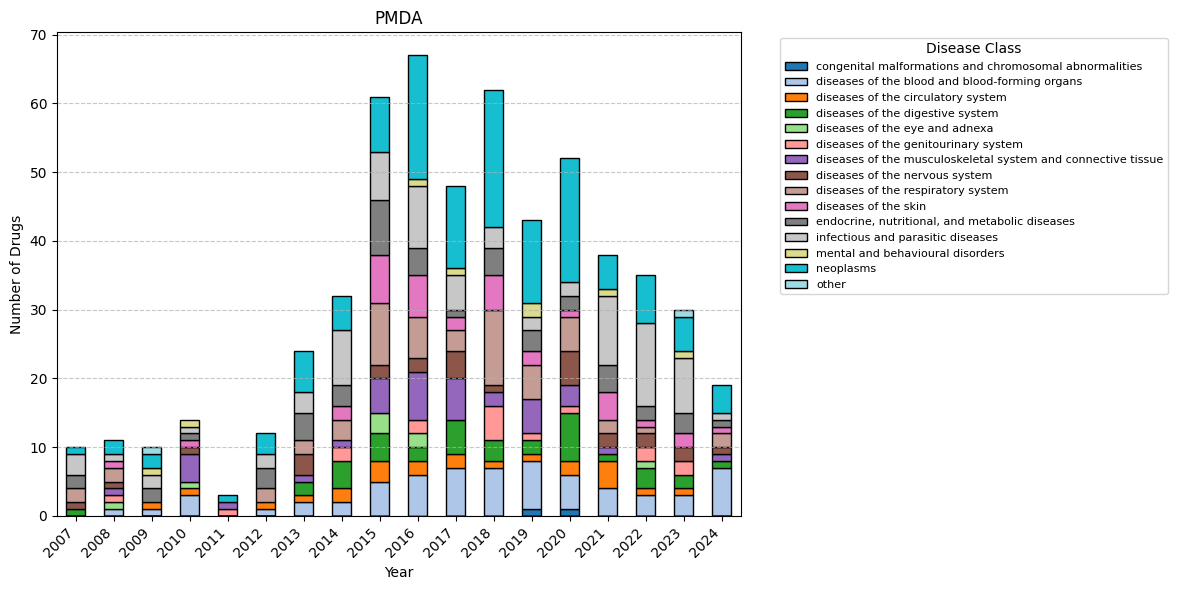

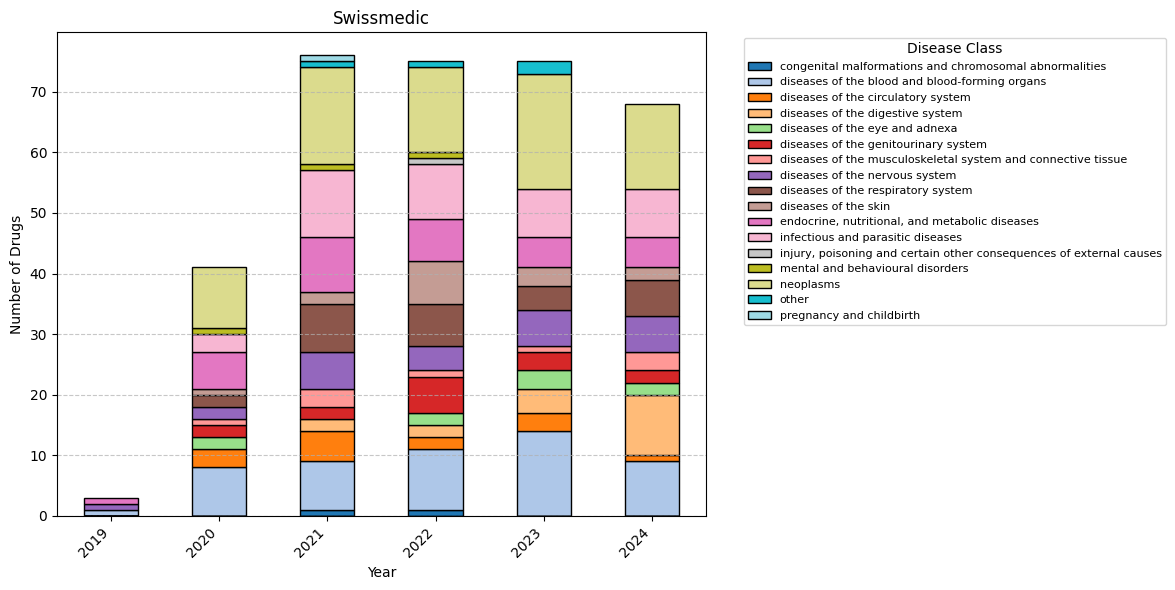

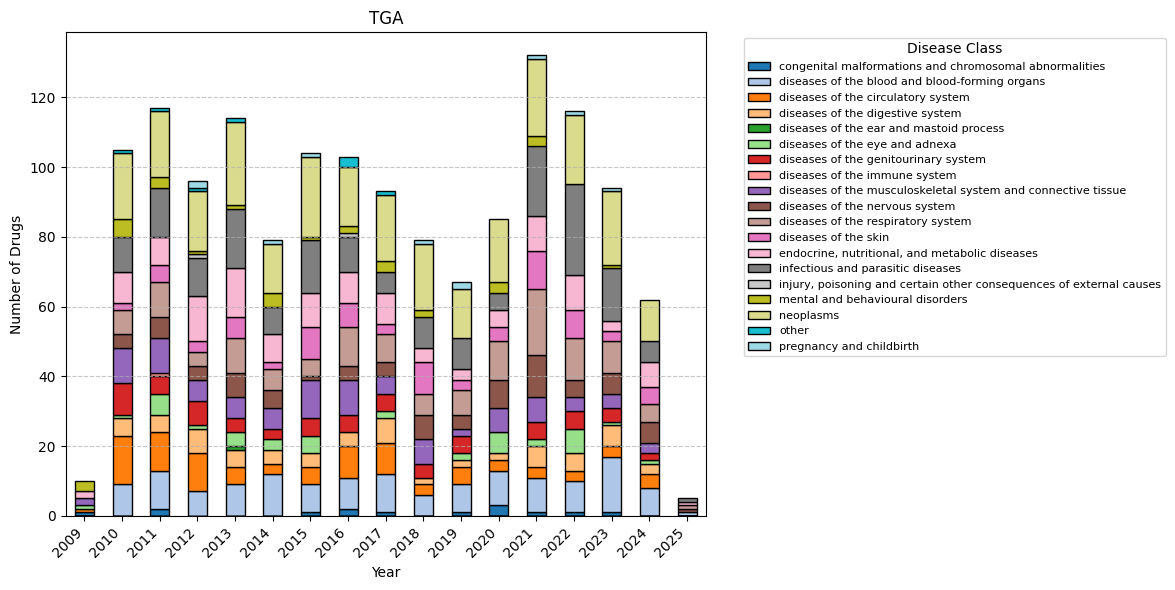

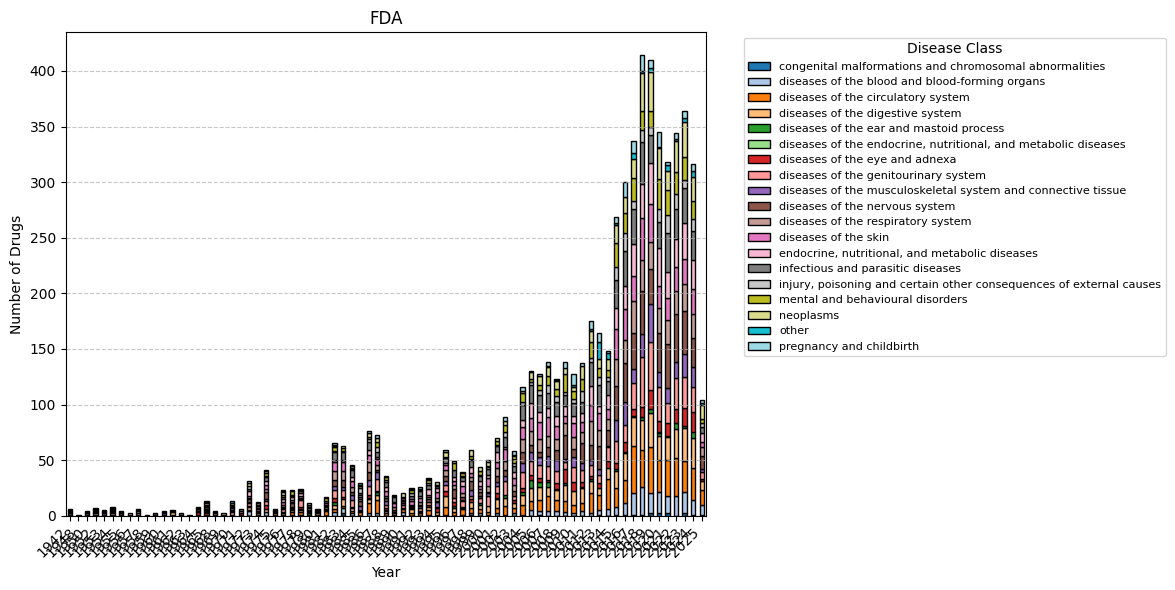

In [154]:
for k,v in DATASETS.items():
    if 'Decision_year' in v.columns and 'Disease_class(es)' in v.columns:
        plot_disease_class_per_decision_year_absolute(v, year_col='Decision_year', disease_class_colormap=None, dataset_name=k)
    else:
        print(f"{k}: 'Decision_year' or 'Disease_class(es)' column not found, skipping disease class per decision year absolute plot.")

EMA: 'Marketing_authorisation_holder_extracted' column not found, skipping marketing holder distribution pie chart.
PMDA: 'Marketing_authorisation_holder_extracted' column not found, skipping marketing holder distribution pie chart.
Swissmedic: 'Marketing_authorisation_holder_extracted' column not found, skipping marketing holder distribution pie chart.
TGA: 'Marketing_authorisation_holder_extracted' column not found, skipping marketing holder distribution pie chart.


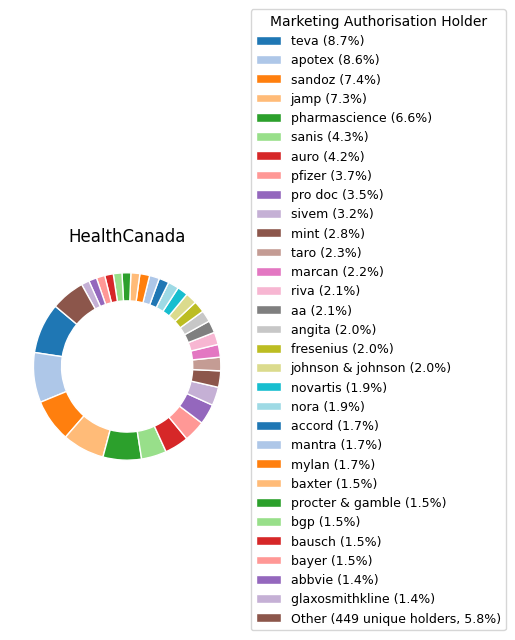

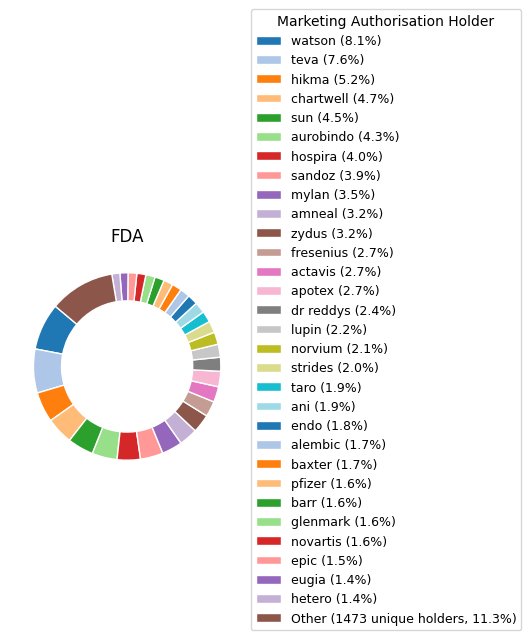

In [155]:
for k,v in DATASETS.items():
    if 'Marketing_authorisation_holder_extracted' in v.columns:
        plot_marketing_holder_distribution_pie(v, dataset_name=k)
    else:
        print(f"{k}: 'Marketing_authorisation_holder_extracted' column not found, skipping marketing holder distribution pie chart.")

In [156]:
all_holders_combined = pd.concat(
    [EMA['Marketing_authorisation_holder'], 
     JAPAN['Marketing_authorisation_holder'], 
     SWISSMEDIC['Marketing_authorisation_holder']
     ])    
all_holders_combined = all_holders_combined.dropna().unique()

def sort_by_name(df, col_name):
    df = df.copy()
    df[col_name] = df[col_name].str.lower().str.strip()
    return df.sort_values(by=col_name)

EMA_sorted = sort_by_name(EMA, 'Marketing_authorisation_holder')
JAPAN_sorted = sort_by_name(JAPAN, 'Marketing_authorisation_holder')
SWISSMEDIC_sorted = sort_by_name(SWISSMEDIC, 'Marketing_authorisation_holder')

EMA_sorted_unique = EMA_sorted['Marketing_authorisation_holder'].unique()
JAPAN_sorted_unique = JAPAN_sorted['Marketing_authorisation_holder'].unique()
SWISSMEDIC_sorted_unique = SWISSMEDIC_sorted['Marketing_authorisation_holder'].unique()

with open(f"{SAVE_DIR}/EMA_marketing_authorisation_holders.txt", 'w', encoding="utf-8") as f:
    for holder in EMA_sorted_unique:
        f.write(f"{holder}\n")
with open(f"{SAVE_DIR}/JAPAN_marketing_authorisation_holders.txt", 'w') as f:
    for holder in JAPAN_sorted_unique:
        f.write(f"{holder}\n")
with open(f"{SAVE_DIR}/SWISSMEDIC_marketing_authorisation_holders.txt", 'w') as f:
    for holder in SWISSMEDIC_sorted_unique:
        f.write(f"{holder}\n")


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:558: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Agency'] = agency
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:558: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Agency'] = agency
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:558: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

HealthCanada: Missing required columns for review duration calculation.
FDA: Missing required columns for review duration calculation.


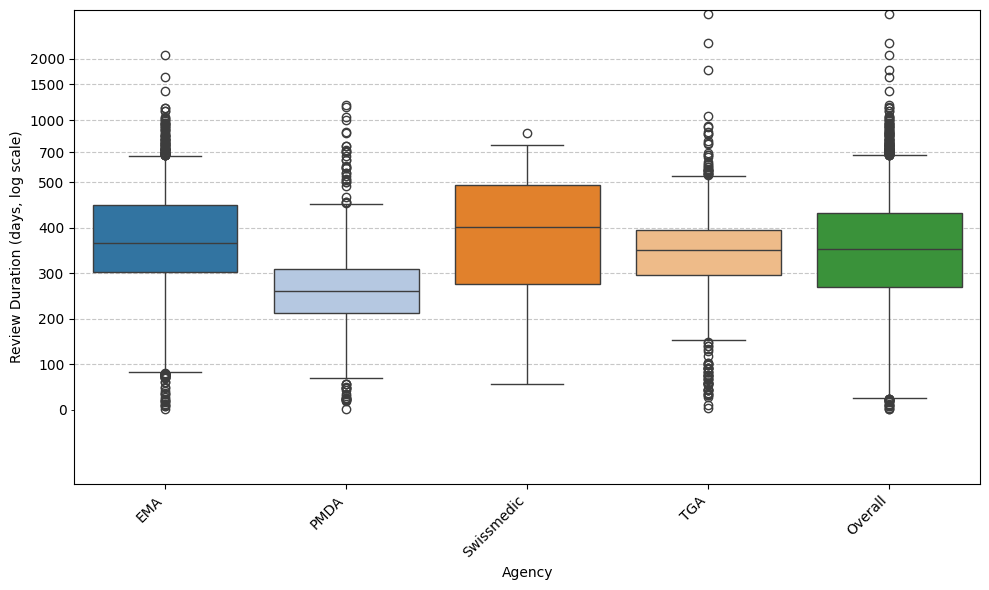

In [157]:
plot_review_duration_by_agency(
    agency_dfs=DATASETS,
    submission_col='Application_date',
    decision_col='Decision_date',
    dataset_name='combined'
)

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:605: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='Disease_class(es)', y='Review_duration_days', palette='tab20')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:605: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='Disease_class(es)', y='Review_duration_days', palette='tab20')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\2109271267.py:605: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='Disease_class(es

HealthCanada: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.
FDA: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.


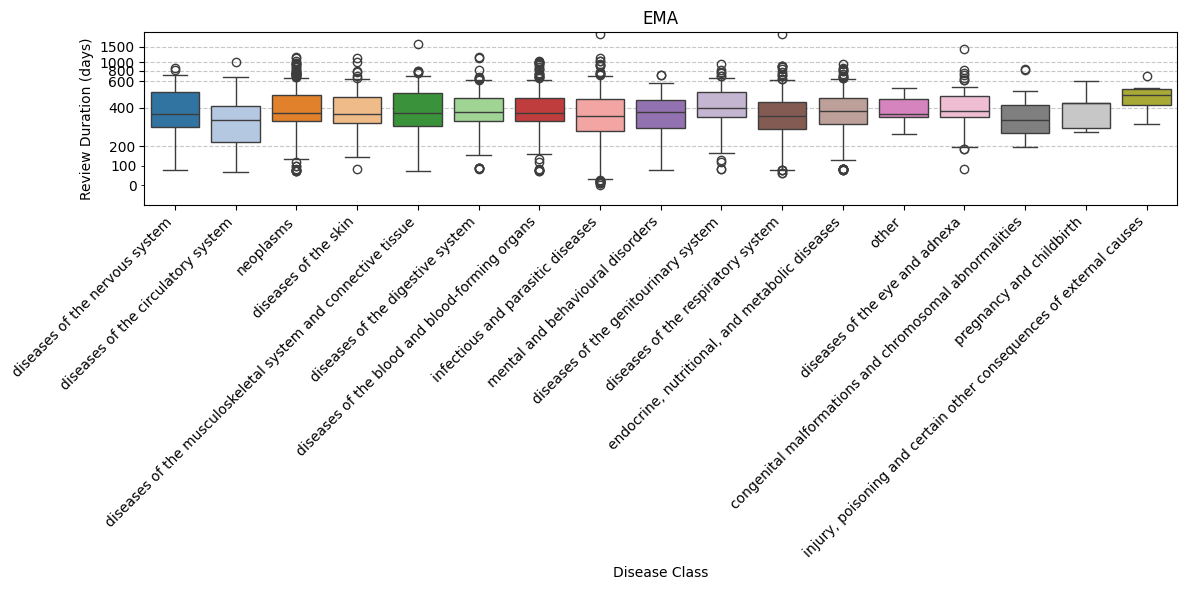

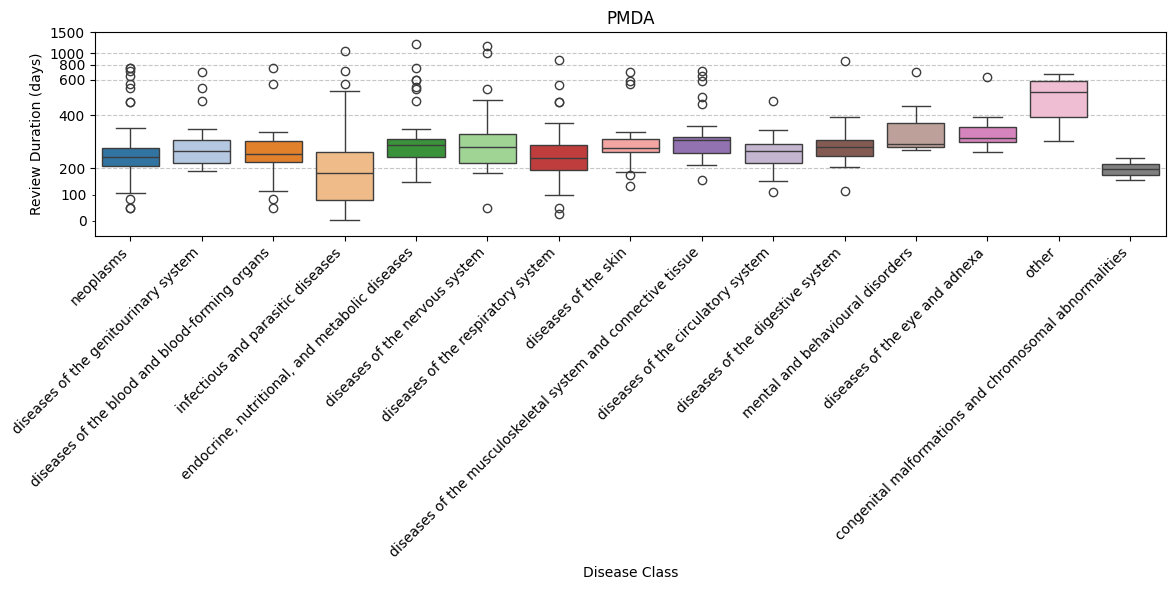

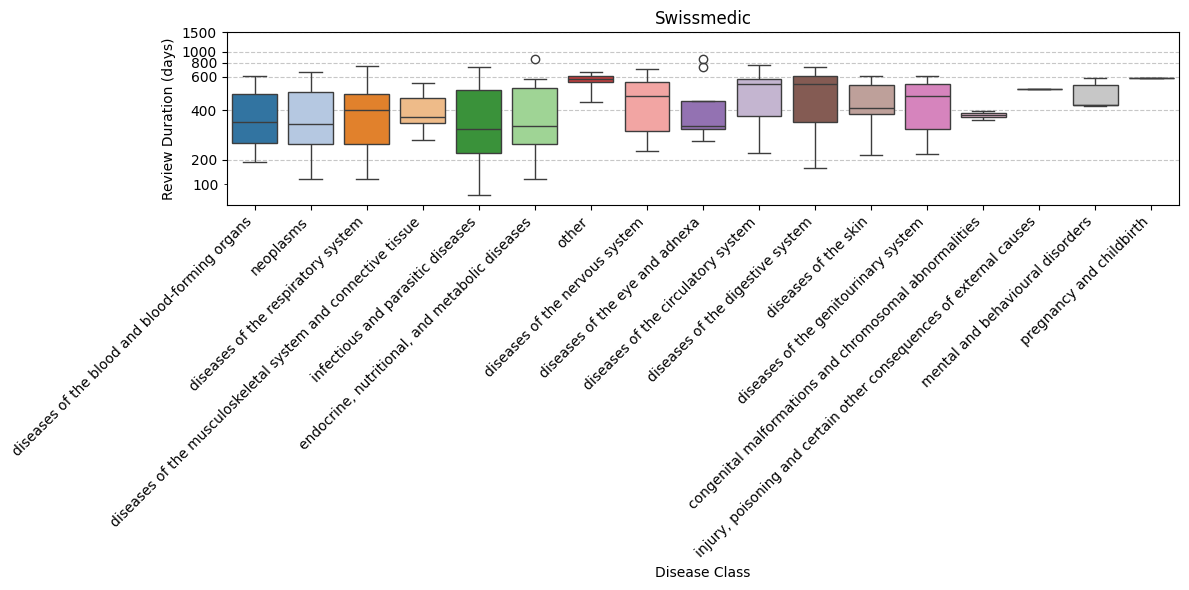

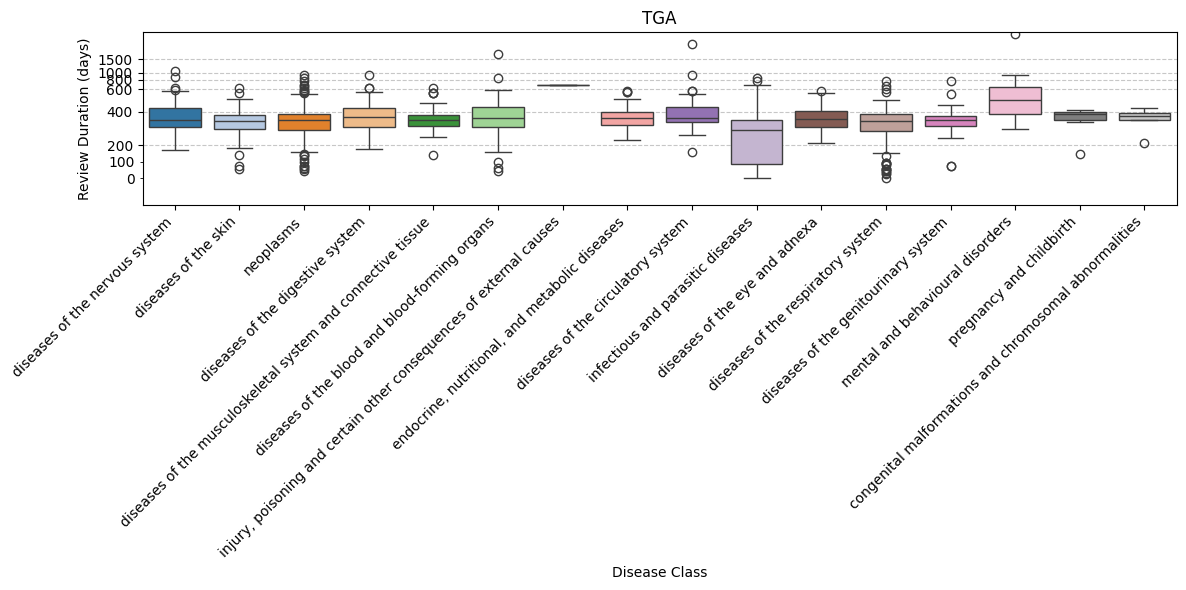

In [158]:
for k,v in DATASETS.items():
    if 'Application_date' in v.columns and 'Decision_date' in v.columns:
        plot_review_duration_by_disease_class(
            v,
            submission_col='Application_date',
            decision_col='Decision_date',
            dataset_name=k
        )
    else:
        print(f"{k}: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.")

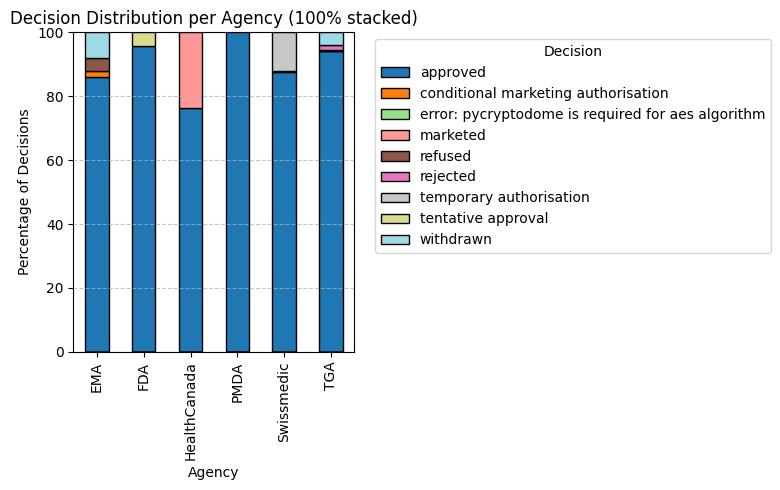

In [159]:
plot_decision_distribution_by_agency(
    agency_dfs=DATASETS,
    dataset_name='combined'
)

HealthCanada: 'Decision_date' or 'Disease_class(es)' column not found, skipping decision breakdown per disease class plot.


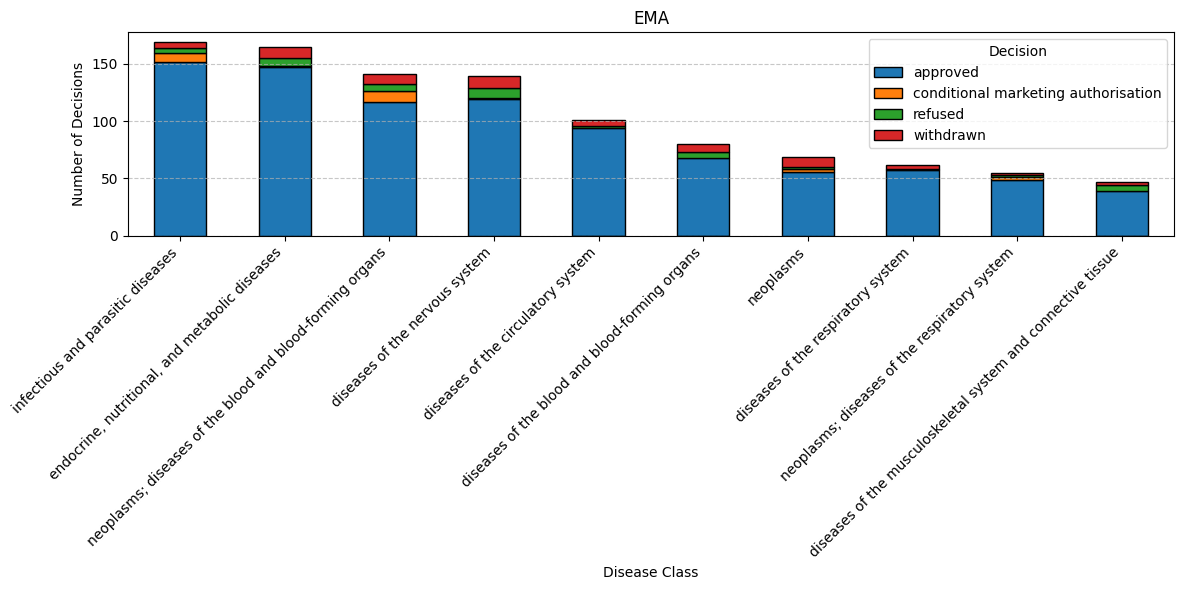

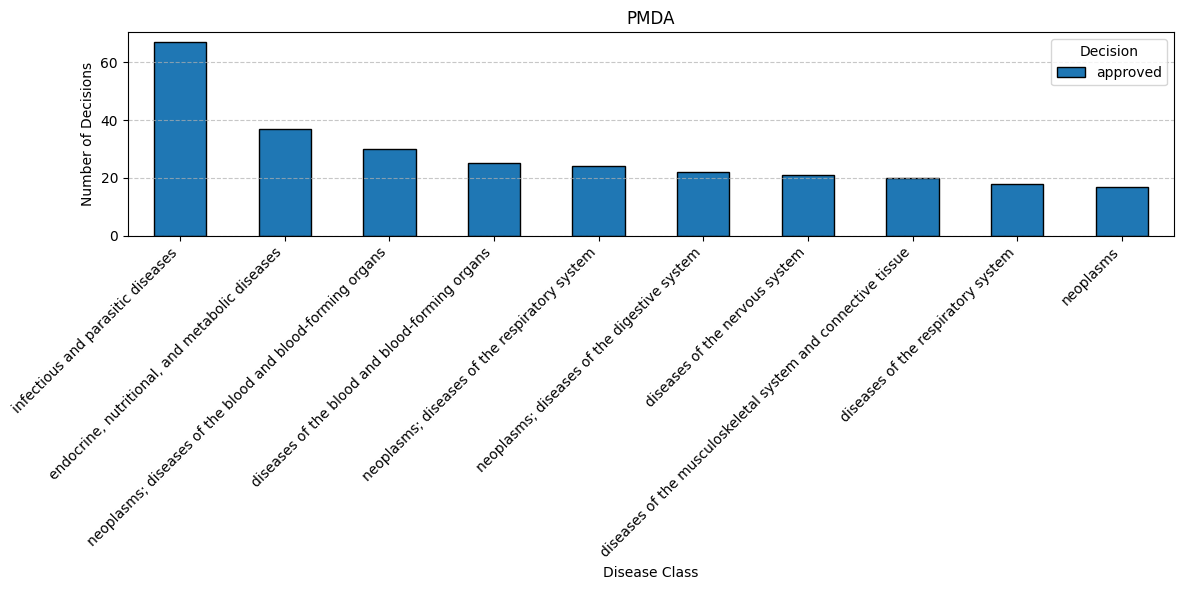

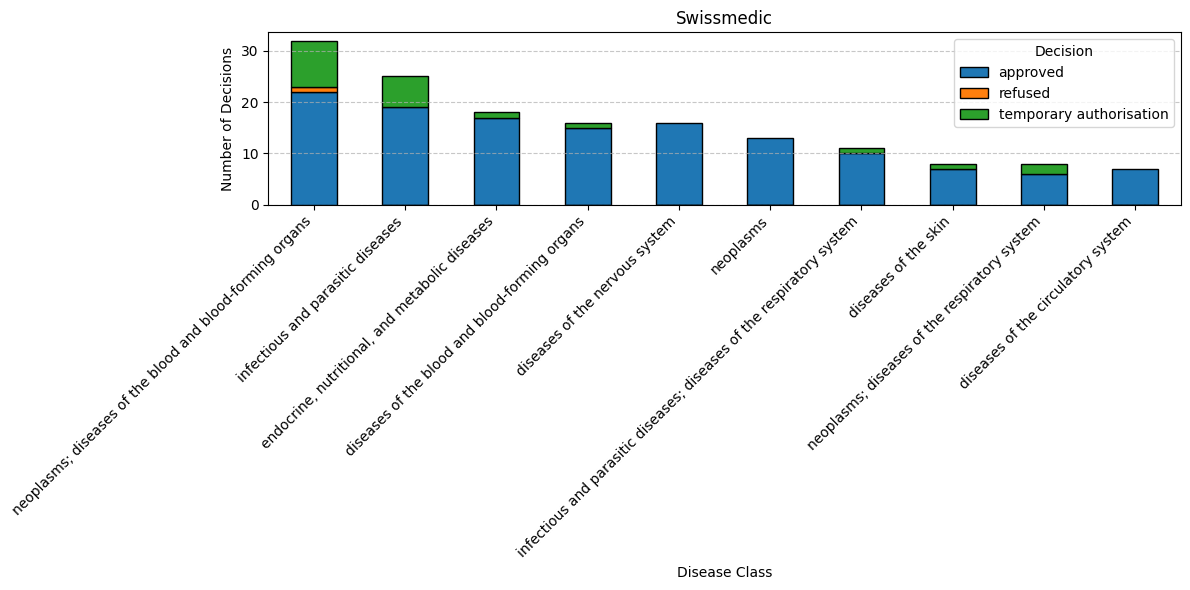

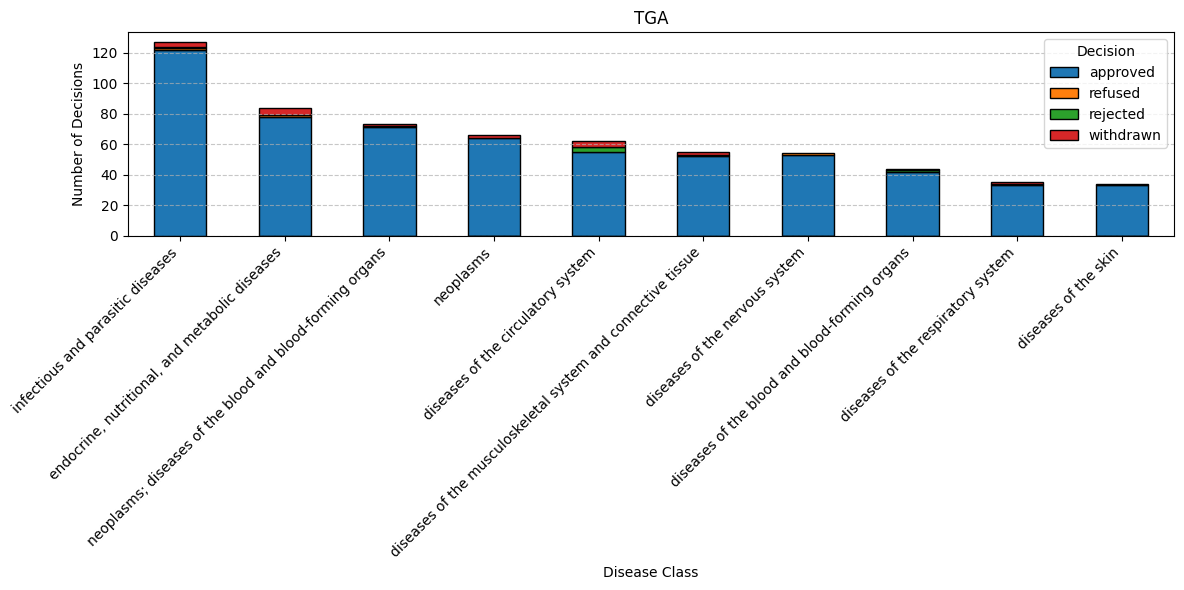

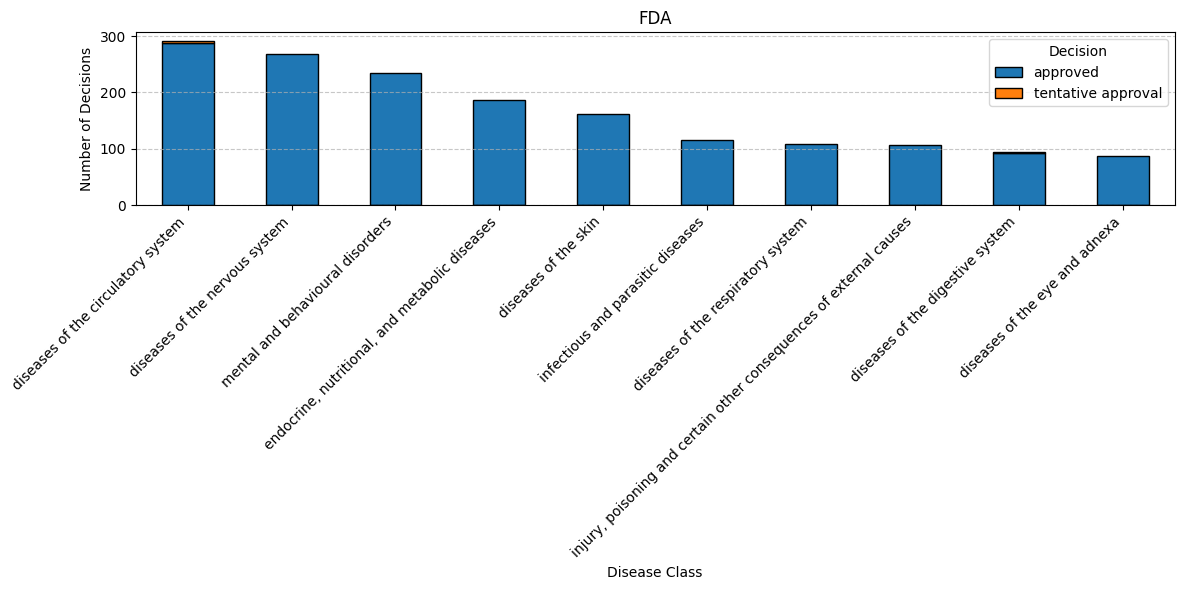

In [160]:
for k,v in DATASETS.items():
    if 'Decision_date' in v.columns and 'Disease_class(es)' in v.columns:
        plot_decision_breakdown_per_disease_class(
            v,
            dataset_name=k,
            date_col='Decision_date'
        )
    else:
        print(f"{k}: 'Decision_date' or 'Disease_class(es)' column not found, skipping decision breakdown per disease class plot.")

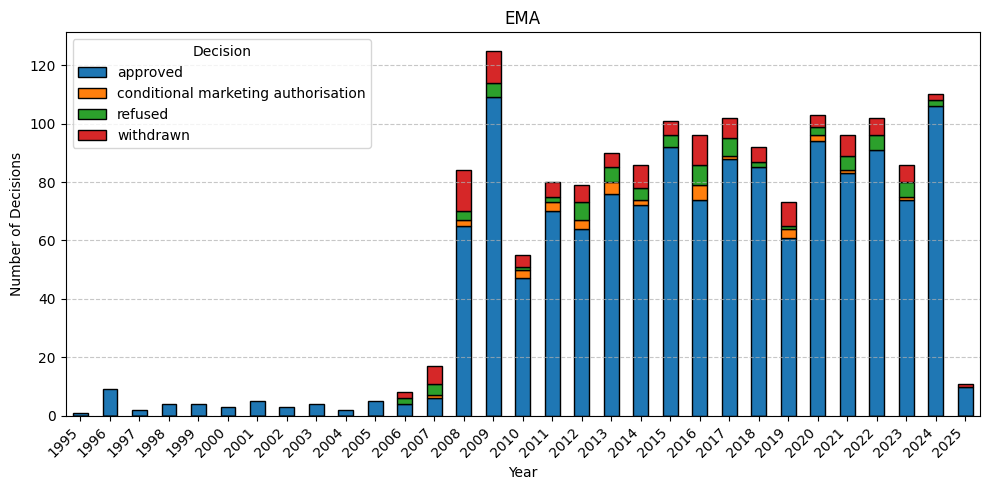

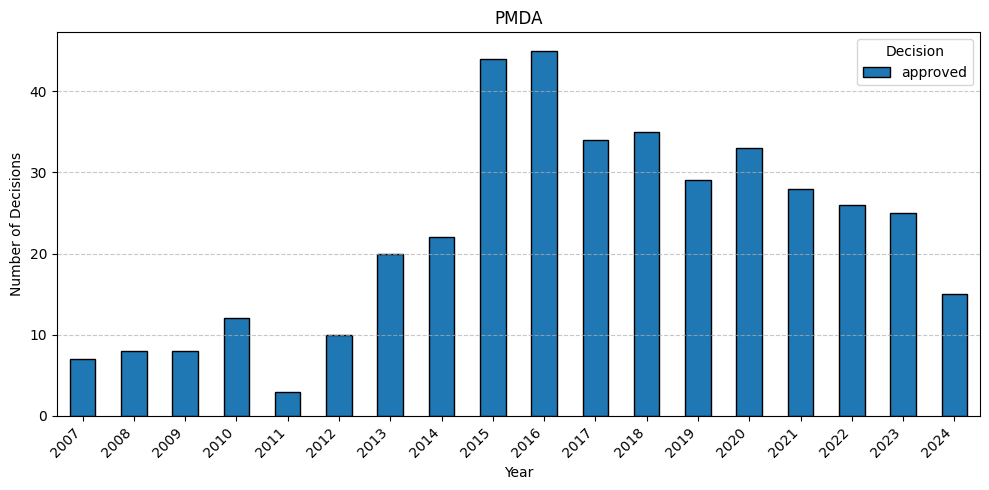

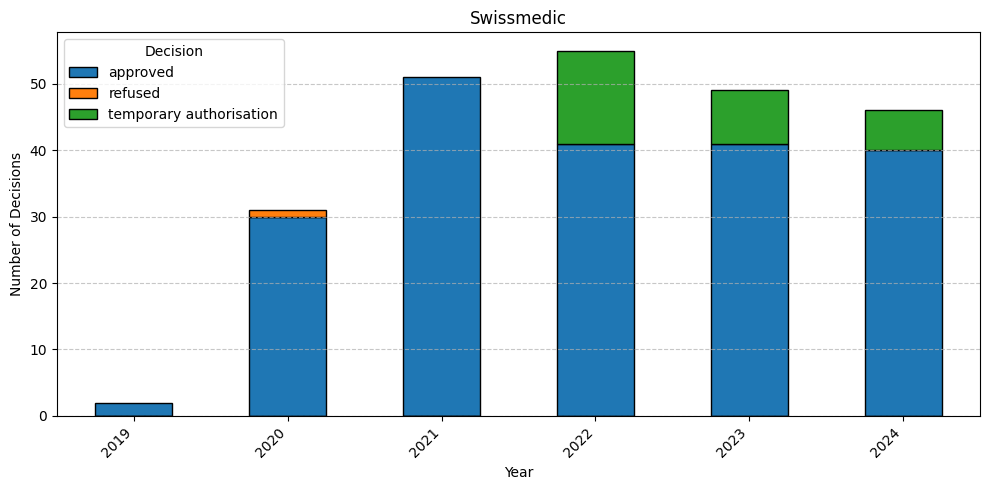

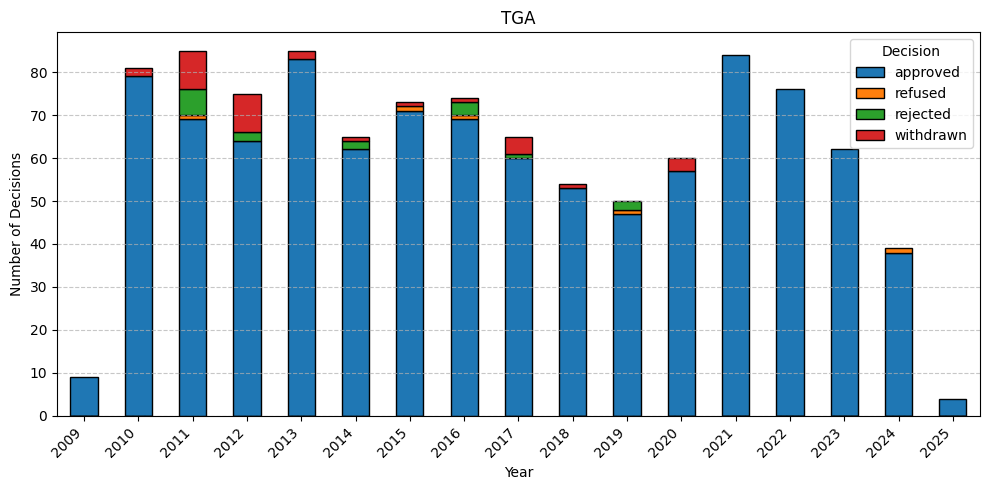

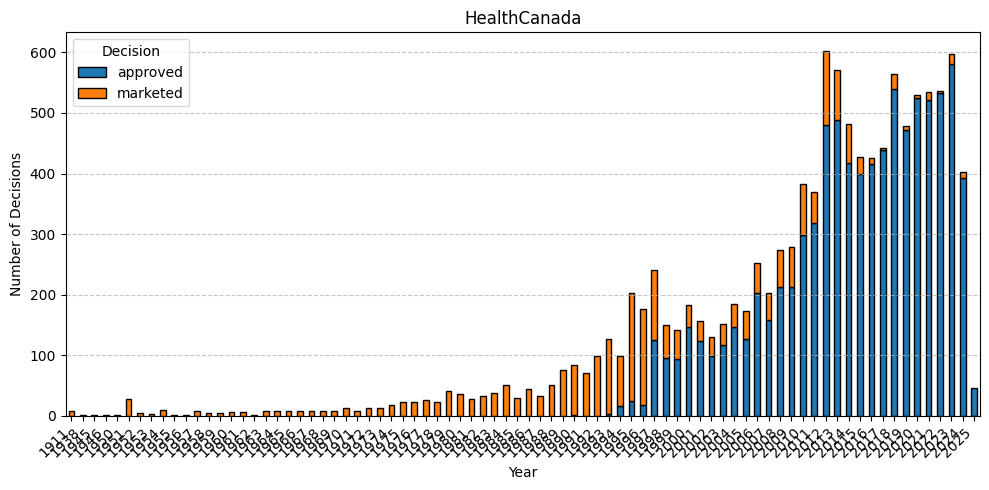

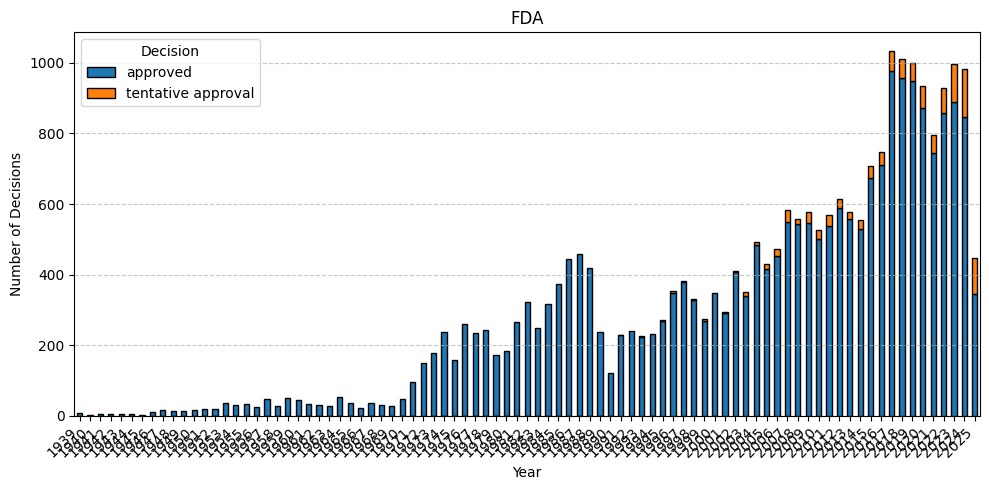

In [161]:
for k,v in DATASETS.items():
    if 'Decision_date' in v.columns:
        plot_decision_breakdown_per_agency_per_year(
            v,
            dataset_name=k,
            date_col='Decision_date'
        )
    else:
        print(f"{k}: 'Decision_date' column not found, skipping decision breakdown per agency plot.")

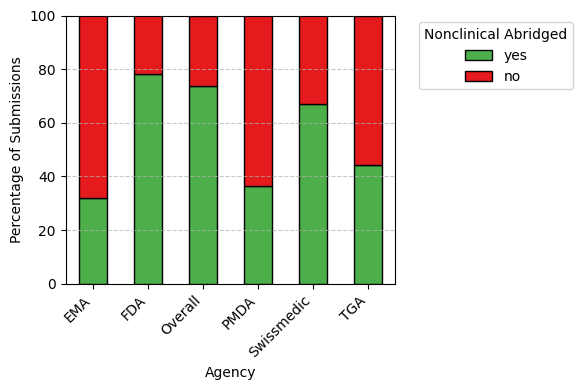

In [162]:
plot_nonclinical_abridged_distribution(
    agency_dfs=DATASETS,
    dataset_name='combined'
)

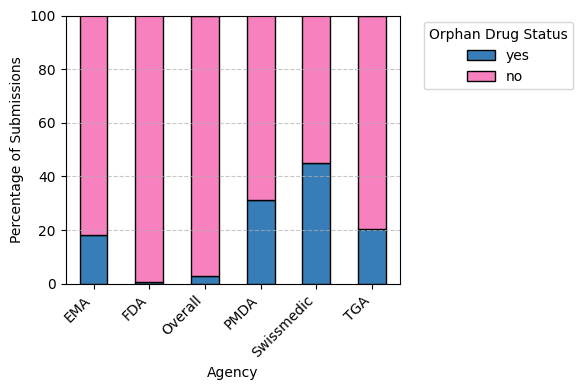

In [163]:
plot_orphan_drug_status_distribution(
    agency_dfs=DATASETS,
    dataset_name='combined'
)

In [164]:
for k,v in DATASETS.items():
    if 'Decision_year' in v.columns:
        plot_all_measures_per_dataset(
            v,
            dataset_name=k,
            date_col='Decision_year'
        )
    else:
        print(f"{k}: 'Decision_year' column not found, skipping all measures for authority plot.")


[OK] ./../inference/combined/figures/deaths_vs_approvals_EMA_Deaths.png
Deaths saved to file.

[OK] ./../inference/combined/figures/dalys_vs_approvals_EMA_DALYs.png
DALYs saved to file.

[OK] ./../inference/combined/figures/incidence_vs_approvals_EMA_Incidence.png
Incidence saved to file.

[OK] ./../inference/combined/figures/prevalence_vs_approvals_EMA_Prevalence.png
Prevalence saved to file.

[OK] ./../inference/combined/figures/deaths_vs_approvals_PMDA_Deaths.png
Deaths saved to file.

[OK] ./../inference/combined/figures/dalys_vs_approvals_PMDA_DALYs.png
DALYs saved to file.

[OK] ./../inference/combined/figures/incidence_vs_approvals_PMDA_Incidence.png
Incidence saved to file.

[OK] ./../inference/combined/figures/prevalence_vs_approvals_PMDA_Prevalence.png
Prevalence saved to file.

[OK] ./../inference/combined/figures/deaths_vs_approvals_Swissmedic_Deaths.png
Deaths saved to file.

[OK] ./../inference/combined/figures/dalys_vs_approvals_Swissmedic_DALYs.png
DALYs saved to file.
